# Strategy 2 — Structured Patient Vector (Eye-Level Aggregation)

**Goal:** Break past the F1 ≈ 0.658 ceiling without fine-tuning the backbone.

## Approach
Instead of classifying **images** and then aggregating predictions via `max()`,
we aggregate **embeddings** per eye, then build a structured patient vector:

```
patient_vector = [left_eye_emb | right_eye_emb | |left_eye - right_eye|]
```

- **Eye-level pooling:** Average the 2 images per eye → `left_emb`, `right_emb`
- **Difference vector:** `|left - right|` captures inter-ocular asymmetry  
  (DR can appear in one eye before the other; the classifier learns "asymmetry = suspicious")
- **Direct patient-level classification** — no post-hoc aggregation leak

### Dimensionality
| Model Dim | Structured Vector | After PCA |
|-----------|------------------|-----------|
| 1024-D    | 3 × 1024 = 3072  | 128       |
| 768-D     | 3 × 768 = 2304   | 128       |

### Expected improvement: +0.03–0.06 F1 over R16b (0.658)

---
**Frozen patient split:** 1,032 train / 259 test (from R14 checkpoint)

In [1]:
# ═══════════════════════════════════════════════════════════════════════════════
# Cell 1 — Imports & Configuration
# ═══════════════════════════════════════════════════════════════════════════════
from __future__ import annotations
import copy, math, json, warnings, os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    f1_score, precision_score, recall_score, balanced_accuracy_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report,
    log_loss,
)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.base import BaseEstimator, ClassifierMixin

import sys
sys.path.insert(0, str(Path.cwd() / 'src'))
from retina_embeddings_dataset import load_retina_embeddings_dataset
from retina_benchmark import list_embeddings_csvs
import retina_evaluation as reval

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

# ─── Paths ─────────────────────────────────────────────────────────────────────
PROJECT_ROOT = Path.cwd()
DATASET_NAME = "mbrset"
VIEW = "all"

embed_dir = PROJECT_ROOT / "data" / "mbrset_embeddings"
labels_path = embed_dir / f"{DATASET_NAME}_labels" / f"labels_{DATASET_NAME}.csv"
embedding_files = sorted(list_embeddings_csvs(embed_dir))

SPLIT_CSV = PROJECT_ROOT / "results" / "mbrset_patient_eval_any_dr" / "patient_split.csv"
RESULTS_DIR = PROJECT_ROOT / "results" / "structured_patient_vector"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# ─── Task ──────────────────────────────────────────────────────────────────────
BINARY_TASKS = ["task_any_dr"]
BINARY_TASK_MAP = {"task_any_dr": "task_any_diab_retino"}

# ─── Model Config ─────────────────────────────────────────────────────────────
PCA_N_COMPONENTS = 128
RANDOM_SEED = 42
THRESHOLD_METHOD = "f1"
THRESHOLD_GRID_SIZE = 201
SHOW_PLOTS = True
SAVE_PLOTS = True
CPU_COUNT = min(os.cpu_count() or 1, 4)

# MLP defaults
MLP_DEFAULTS = {
    "hidden_layer_sizes": (256, 128),
    "alpha": 0.06,
    "learning_rate_init": 0.0005,
    "batch_size": 64,
    "max_epochs": 300,
    "patience": 50,
    "lr_schedule": "cosine",
    "warmup_epochs": 10,
    "lr_min": 1e-5,
}

# Per-embedding alpha overrides (from R14/R15c)
ALPHA_OVERRIDES = {
    "Embeddings_mbrset_dinov3_convnext_base": 0.03,
    "Embeddings_mbrset_RETFound_mae_shanghai": 0.07,
    "Embeddings_mbrset_RETFound_mae_natureCFP": 0.03,
    "Embeddings_mbrset_RETFound_dinov2_shanghai": 0.05,
    "Embeddings_vit_base_mbrset": 0.05,
    "Embeddings_convnextv2_base_mbrset": 0.05,
}

def resolve_config(emb_stem):
    cfg = dict(MLP_DEFAULTS)
    if emb_stem in ALPHA_OVERRIDES:
        cfg["alpha"] = ALPHA_OVERRIDES[emb_stem]
    return cfg

print(f"Project root: {PROJECT_ROOT}")
print(f"Embeddings: {len(embedding_files)} files")
for f in embedding_files:
    print(f"  - {f.stem}")
print(f"Labels: {labels_path}")
print(f"Split: {SPLIT_CSV}")
print(f"Results dir: {RESULTS_DIR}")
print(f"PCA components: {PCA_N_COMPONENTS}")

Project root: c:\Users\Julian\OneDrive\Desktop\testing-retina-project\Retina-Project-Evaluation\main-project
Embeddings: 7 files
  - Embeddings_convnextv2_base_mbrset
  - Embeddings_mbrset_dinov3_convnext_base
  - Embeddings_mbrset_dinov3_vitb16
  - Embeddings_mbrset_RETFound_dinov2_shanghai
  - Embeddings_mbrset_RETFound_mae_natureCFP
  - Embeddings_mbrset_RETFound_mae_shanghai
  - Embeddings_vit_base_mbrset
Labels: c:\Users\Julian\OneDrive\Desktop\testing-retina-project\Retina-Project-Evaluation\main-project\data\mbrset_embeddings\mbrset_labels\labels_mbrset.csv
Split: c:\Users\Julian\OneDrive\Desktop\testing-retina-project\Retina-Project-Evaluation\main-project\results\mbrset_patient_eval_any_dr\patient_split.csv
Results dir: c:\Users\Julian\OneDrive\Desktop\testing-retina-project\Retina-Project-Evaluation\main-project\results\structured_patient_vector
PCA components: 128


In [2]:
# ═══════════════════════════════════════════════════════════════════════════════
# Cell 2 — Load Patient Split (frozen from R14)
# ═══════════════════════════════════════════════════════════════════════════════
_split_df = pd.read_csv(SPLIT_CSV)
_split_df['patient_id'] = _split_df['patient_id'].astype(str)

train_patient_ids = set(_split_df[_split_df['split'] == 'train']['patient_id'])
test_patient_ids = set(_split_df[_split_df['split'] == 'test']['patient_id'])

print(f"Train patients: {len(train_patient_ids)}")
print(f"Test patients:  {len(test_patient_ids)}")
print(f"Total:          {len(train_patient_ids) + len(test_patient_ids)}")

# Copy split to results
split_info = _split_df.copy()
split_info.to_csv(RESULTS_DIR / "patient_split.csv", index=False)
print(f"Copied split to: {RESULTS_DIR / 'patient_split.csv'}")

Train patients: 1032
Test patients:  259
Total:          1291
Copied split to: c:\Users\Julian\OneDrive\Desktop\testing-retina-project\Retina-Project-Evaluation\main-project\results\structured_patient_vector\patient_split.csv


## 3. Structured Patient Vector Builder

For each patient:
1. Group images by eye (laterality: right = `.1`,`.2` / left = `.3`,`.4`)
2. Mean-pool same-eye images → `left_emb` (D), `right_emb` (D)
3. Build: `patient_vec = [left_emb | right_emb | |left_emb - right_emb|]` → 3×D
4. Label: `max()` across all images (positive if ANY image is positive)

In [3]:
# ═══════════════════════════════════════════════════════════════════════════════
# Cell 3 — Structured Patient Vector Builder
# ═══════════════════════════════════════════════════════════════════════════════

def build_structured_patient_vectors(
    df: pd.DataFrame,
    feature_cols: list[str],
    label_col: str = "task_any_dr",
    patient_col: str = "patient_id",
    laterality_col: str = "laterality",
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Build structured patient vectors from image-level embeddings.
    
    For each patient:
      - Pool right-eye images → right_emb (mean of available right-eye embeddings)
      - Pool left-eye images  → left_emb  (mean of available left-eye embeddings)
      - Build: [left_emb | right_emb | |left_emb - right_emb|] → 3×D vector
    
    Handles edge cases:
      - Patient with only one eye: missing eye filled with the available eye's embedding
        (difference vector becomes zero → classifier knows there's no asymmetry info)
      - Patient with all images missing labels: skipped
    
    Args:
        df: Merged embeddings + labels DataFrame (image-level rows)
        feature_cols: List of embedding feature column names
        label_col: Binary label column
        patient_col: Patient ID column
        laterality_col: Column with 'left'/'right' values
    
    Returns:
        (patient_ids, X_structured, y_labels)
        X_structured shape: (n_patients, 3 * embed_dim)
    """
    patient_ids = []
    X_list = []
    y_list = []
    skipped = 0
    one_eye_count = 0
    
    for pid, group in df.groupby(patient_col):
        # Get label (positive if ANY image is positive)
        label_vals = group[label_col].dropna()
        if label_vals.empty:
            skipped += 1
            continue
        label = int(label_vals.max())
        
        # Split by laterality
        lat = group[laterality_col].astype(str).str.lower().str.strip()
        right_mask = lat == 'right'
        left_mask = lat == 'left'
        
        right_imgs = group.loc[right_mask, feature_cols].to_numpy(dtype=np.float32)
        left_imgs = group.loc[left_mask, feature_cols].to_numpy(dtype=np.float32)
        
        # Pool per eye (mean)
        has_right = len(right_imgs) > 0
        has_left = len(left_imgs) > 0
        
        if not has_right and not has_left:
            skipped += 1
            continue
        
        if has_right and has_left:
            right_emb = right_imgs.mean(axis=0)
            left_emb = left_imgs.mean(axis=0)
        elif has_right:
            right_emb = right_imgs.mean(axis=0)
            left_emb = right_emb.copy()  # Fill missing eye
            one_eye_count += 1
        else:
            left_emb = left_imgs.mean(axis=0)
            right_emb = left_emb.copy()  # Fill missing eye
            one_eye_count += 1
        
        # Build structured vector: [left | right | |left - right|]
        diff = np.abs(left_emb - right_emb)
        patient_vec = np.concatenate([left_emb, right_emb, diff])
        
        patient_ids.append(pid)
        X_list.append(patient_vec)
        y_list.append(label)
    
    if skipped:
        print(f"  [build_spv] Skipped {skipped} patients (no valid labels or embeddings)")
    if one_eye_count:
        print(f"  [build_spv] {one_eye_count} patients had only one eye — filled with copy")
    
    return (
        np.array(patient_ids),
        np.array(X_list, dtype=np.float32),
        np.array(y_list, dtype=int),
    )


# Quick validation on first embedding
print("Validating structured patient vector builder...")
ds_test = load_retina_embeddings_dataset(
    dataset=DATASET_NAME,
    embeddings_csv_path=embedding_files[0],
    labels_csv_path=labels_path,
    view=VIEW,
)
test_df_check = ds_test.df.copy()
test_df_check['patient_id'] = test_df_check['patient_id'].astype(str)
pids, X_spv, y_spv = build_structured_patient_vectors(
    test_df_check, ds_test.feature_cols
)
embed_dim = len(ds_test.feature_cols)
print(f"  Embedding dim: {embed_dim}")
print(f"  Structured vector dim: {X_spv.shape[1]} (3 × {embed_dim} = {3 * embed_dim})")
print(f"  Patients: {len(pids)}")
print(f"  Label distribution: {dict(zip(*np.unique(y_spv, return_counts=True)))}")
print(f"  DR prevalence: {y_spv.mean():.1%}")
assert X_spv.shape[1] == 3 * embed_dim, "Dimension mismatch!"
print("  ✓ Validation passed")

Validating structured patient vector builder...
  [build_spv] Skipped 4 patients (no valid labels or embeddings)
  Embedding dim: 1024
  Structured vector dim: 3072 (3 × 1024 = 3072)
  Patients: 1287
  Label distribution: {np.int64(0): np.int64(892), np.int64(1): np.int64(395)}
  DR prevalence: 30.7%
  ✓ Validation passed


In [4]:
# ═══════════════════════════════════════════════════════════════════════════════
# Cell 4 — Helper Functions (MLP training, threshold, etc.)
# ═══════════════════════════════════════════════════════════════════════════════

def compute_class_weight_mapping(y, mode="balanced", manual_class_weight=None, damping_gamma=1.0):
    y = np.asarray(y)
    classes = np.unique(y)
    if classes.size == 0:
        return {}
    if mode == "none":
        mapping = {int(c): 1.0 for c in classes}
    elif mode == "manual":
        manual_class_weight = manual_class_weight or {}
        mapping = {int(c): float(manual_class_weight.get(int(c), 1.0)) for c in classes}
    elif mode == "balanced":
        w = compute_class_weight(class_weight="balanced", classes=classes, y=y)
        mapping = {int(c): float(wi) for c, wi in zip(classes, w)}
    else:
        raise ValueError(f"Unknown mode: {mode}")
    if damping_gamma is not None and float(damping_gamma) != 1.0:
        gamma = float(damping_gamma)
        mapping = {c: float(w ** gamma) for c, w in mapping.items()}
    return mapping


def compute_sample_weights(y, class_weight_mapping, normalize=True):
    y = np.asarray(y)
    if y.size == 0:
        return np.asarray([], dtype=np.float32)
    sw = np.array([class_weight_mapping.get(int(lbl), 1.0) for lbl in y], dtype=np.float32)
    if normalize and sw.size:
        mean_w = float(np.mean(sw))
        if mean_w > 0:
            sw = sw / mean_w
    return sw


def safe_fit_with_optional_sample_weight(estimator, X, y, sample_weight=None):
    if sample_weight is None:
        estimator.fit(X, y)
        return False
    try:
        estimator.fit(X, y, sample_weight=sample_weight)
        return True
    except TypeError:
        estimator.fit(X, y)
        return False


def find_optimal_threshold(y_true, y_proba, method="f1", grid_size=201):
    y_true = np.asarray(y_true)
    y_proba = np.asarray(y_proba)
    if y_true.size == 0:
        return 0.5
    if method == "youden":
        fpr, tpr, thresholds = roc_curve(y_true, y_proba)
        j_scores = tpr - fpr
        best_idx = int(np.argmax(j_scores))
        return float(thresholds[best_idx])
    if method == "f1":
        grid_size = max(11, min(int(grid_size), 1001))
        thresholds = np.linspace(0.01, 0.99, grid_size)
        best_t, best_f1 = 0.5, -1.0
        for t in thresholds:
            y_pred = (y_proba >= t).astype(int)
            f1 = float(f1_score(y_true, y_pred, zero_division=0))
            if f1 > best_f1:
                best_f1 = f1
                best_t = float(t)
        return best_t
    raise ValueError(f"Unknown method: {method}")


def weighted_log_loss(y_true, y_proba, labels, sample_weight=None):
    return log_loss(y_true, y_proba, labels=labels, sample_weight=sample_weight)


# ——— Cosine LR schedule ———
def cosine_lr(epoch, max_epochs, lr_init, lr_min=1e-5, warmup_epochs=10):
    if epoch <= warmup_epochs:
        return lr_min + (lr_init - lr_min) * (epoch / max(1, warmup_epochs))
    progress = (epoch - warmup_epochs) / max(1, max_epochs - warmup_epochs)
    return lr_min + 0.5 * (lr_init - lr_min) * (1 + math.cos(math.pi * progress))


def train_mlp_with_schedule(X_train, y_train, X_val, y_val, mlp_cfg,
                             sample_weight_train=None, sample_weight_val=None,
                             random_seed=42):
    lr_init = mlp_cfg["learning_rate_init"]
    lr_min = mlp_cfg.get("lr_min", 1e-5)
    lr_schedule = mlp_cfg.get("lr_schedule", "constant")
    warmup = mlp_cfg.get("warmup_epochs", 0)
    max_epochs = mlp_cfg["max_epochs"]
    patience = mlp_cfg["patience"]
    min_delta = mlp_cfg.get("min_delta", 1e-4)

    epoch1_lr = cosine_lr(1, max_epochs, lr_init, lr_min, warmup) if lr_schedule == "cosine" else lr_init

    mlp = MLPClassifier(
        hidden_layer_sizes=mlp_cfg["hidden_layer_sizes"],
        alpha=mlp_cfg["alpha"],
        learning_rate_init=epoch1_lr,
        batch_size=mlp_cfg["batch_size"],
        max_iter=1,
        warm_start=True,
        early_stopping=False,
        random_state=random_seed,
    )

    train_losses, val_losses = [], []
    best_val_loss = float("inf")
    best_epoch = 0
    best_model = None
    patience_counter = 0
    labels = np.unique(np.concatenate([y_train, y_val]))

    for epoch in range(1, max_epochs + 1):
        if lr_schedule == "cosine" and epoch > 1 and hasattr(mlp, '_optimizer'):
            new_lr = cosine_lr(epoch, max_epochs, lr_init, lr_min, warmup)
            mlp._optimizer.learning_rate = new_lr

        safe_fit_with_optional_sample_weight(mlp, X_train, y_train, sample_weight=sample_weight_train)

        train_proba = mlp.predict_proba(X_train)
        val_proba = mlp.predict_proba(X_val)

        tr_loss = float(weighted_log_loss(y_train, train_proba, labels=labels, sample_weight=sample_weight_train))
        va_loss = float(weighted_log_loss(y_val, val_proba, labels=labels, sample_weight=sample_weight_val))

        train_losses.append(tr_loss)
        val_losses.append(va_loss)

        if va_loss < best_val_loss - min_delta:
            best_val_loss = va_loss
            best_epoch = epoch
            best_model = copy.deepcopy(mlp)
            patience_counter = 0
        elif epoch > warmup:
            patience_counter += 1
            if patience_counter >= patience:
                break

    return best_model, best_epoch, train_losses, val_losses


def plot_confusion_matrix(cm, title, save_path=None, show=True):
    cm = np.asarray(cm)
    fig, ax = plt.subplots(figsize=(5.2, 4.6))
    im = ax.imshow(cm, cmap="viridis", interpolation="nearest")
    ax.set_title(title, fontsize=11, pad=12)
    ax.set_xlabel("Predicted", fontsize=10)
    ax.set_ylabel("True", fontsize=10)
    ax.set_xticks(range(cm.shape[1]))
    ax.set_yticks(range(cm.shape[0]))
    thresh = cm.max() / 2.0 if cm.size else 0
    for (i, j), val in np.ndenumerate(cm):
        ax.text(j, i, f"{val}", ha="center", va="center",
                color="white" if val > thresh else "black", fontsize=10, fontweight="bold")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=160, bbox_inches="tight")
    if show:
        plt.show()
    else:
        plt.close(fig)


def plot_roc_curve(fpr, tpr, auc, title, save_path=None, show=True):
    fig, ax = plt.subplots(figsize=(5.2, 4.6))
    points = np.array([fpr, tpr]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    norm = Normalize(vmin=0.0, vmax=1.0)
    lc = LineCollection(segments, cmap="plasma", norm=norm)
    lc.set_array(fpr)
    lc.set_linewidth(2.6)
    ax.add_collection(lc)
    ax.plot([0, 1], [0, 1], linestyle="--", color="#666", linewidth=1.2, label="Chance")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_title(f"{title}\nAUC = {auc:.3f}", fontsize=11, pad=12)
    ax.set_xlabel("False Positive Rate", fontsize=10)
    ax.set_ylabel("True Positive Rate", fontsize=10)
    ax.legend(loc="lower right", fontsize=9)
    fig.colorbar(lc, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=160, bbox_inches="tight")
    if show:
        plt.show()
    else:
        plt.close(fig)


print("Helper functions defined.")

Helper functions defined.


## 5. Weight Sweep (Patient-Level, Structured Vectors)

For each embedding, find the optimal `pos_class_weight` on an inner 85/15 split
of the training patients.

In [5]:
# ═══════════════════════════════════════════════════════════════════════════════
# Cell 5 — Weight Sweep on Structured Patient Vectors
# ═══════════════════════════════════════════════════════════════════════════════

SWEEP_POS_WEIGHTS = [1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2, 2.4, 2.6, 2.8, 3.0,
                     3.2, 3.6, 4.0, 4.5, 5.0, 5.5, 6.0, 6.5, 7.0, 7.5, 8.0]
SWEEP_THRESHOLD_FLOOR = 0.20
SWEEP_INNER_VAL_FRAC = 0.15
SWEEP_RANDOM_SEED = RANDOM_SEED + 777

WEIGHTING_OVERRIDES = {}
THRESHOLD_OVERRIDES = {}

print(f"[Weight sweep] Starting per-embedding sweep on structured patient vectors...")
print(f"  Inner val fraction: {SWEEP_INNER_VAL_FRAC}")
print(f"  Pos weights: {SWEEP_POS_WEIGHTS}")
print(f"  Threshold floor: {SWEEP_THRESHOLD_FLOOR}")

thresholds_sweep = np.linspace(0.01, 0.99, THRESHOLD_GRID_SIZE)
thresholds_sweep = thresholds_sweep[thresholds_sweep >= SWEEP_THRESHOLD_FLOOR]

sweep_rows = []

for emb_path in embedding_files:
    emb_stem = emb_path.stem
    print(f"\n--- {emb_stem} ---")
    
    ds = load_retina_embeddings_dataset(
        dataset=DATASET_NAME, embeddings_csv_path=emb_path,
        labels_csv_path=labels_path, view=VIEW,
    )
    all_df = ds.df.copy()
    all_df['patient_id'] = all_df['patient_id'].astype(str)
    train_imgs = all_df[all_df['patient_id'].isin(train_patient_ids)].copy()
    
    task = BINARY_TASKS[0]
    train_imgs = train_imgs.dropna(subset=[task])
    if train_imgs.empty:
        continue
    
    # Build structured patient vectors for training patients
    pids, X_spv, y_spv = build_structured_patient_vectors(
        train_imgs, ds.feature_cols, label_col=task
    )
    
    # Inner patient split (for threshold/weight optimization)
    from sklearn.model_selection import train_test_split
    inner_idx_tr, inner_idx_va = train_test_split(
        np.arange(len(y_spv)), test_size=SWEEP_INNER_VAL_FRAC,
        random_state=SWEEP_RANDOM_SEED, stratify=y_spv,
    )
    X_tr, X_va = X_spv[inner_idx_tr], X_spv[inner_idx_va]
    y_tr, y_va = y_spv[inner_idx_tr], y_spv[inner_idx_va]
    
    # PCA + Scale
    pca_sw = PCA(n_components=PCA_N_COMPONENTS, random_state=RANDOM_SEED)
    X_tr_pca = pca_sw.fit_transform(X_tr)
    X_va_pca = pca_sw.transform(X_va)
    scaler_sw = StandardScaler()
    X_tr_s = scaler_sw.fit_transform(X_tr_pca)
    X_va_s = scaler_sw.transform(X_va_pca)
    
    mlp_cfg = resolve_config(emb_stem)
    best = None
    
    for w_pos in SWEEP_POS_WEIGHTS:
        cw = {0: 1.0, 1: float(w_pos)}
        sw = compute_sample_weights(y_tr, cw, normalize=True)
        
        mlp = MLPClassifier(
            hidden_layer_sizes=mlp_cfg["hidden_layer_sizes"],
            alpha=mlp_cfg["alpha"],
            learning_rate_init=mlp_cfg["learning_rate_init"],
            batch_size=mlp_cfg["batch_size"],
            max_iter=mlp_cfg["max_epochs"],
            early_stopping=True,
            validation_fraction=0.15,
            n_iter_no_change=mlp_cfg["patience"],
            random_state=SWEEP_RANDOM_SEED,
        )
        safe_fit_with_optional_sample_weight(mlp, X_tr_s, y_tr, sample_weight=sw)
        
        va_proba = mlp.predict_proba(X_va_s)[:, 1]
        
        # Direct patient-level threshold sweep (no aggregation needed!)
        best_t, best_f1, best_p, best_r = 0.5, -1.0, 0.0, 0.0
        for t in thresholds_sweep:
            yp = (va_proba >= t).astype(int)
            f1v = float(f1_score(y_va, yp, zero_division=0))
            if f1v > best_f1:
                best_f1 = f1v
                best_t = float(t)
                best_p = float(precision_score(y_va, yp, zero_division=0))
                best_r = float(recall_score(y_va, yp, zero_division=0))
        
        auc_val = float(roc_auc_score(y_va, va_proba)) if len(np.unique(y_va)) == 2 else float("nan")
        
        cand = {
            "embedding": emb_stem,
            "task": task,
            "pos_weight": float(w_pos),
            "threshold": float(best_t),
            "val_f1": float(best_f1),
            "val_precision": float(best_p),
            "val_recall": float(best_r),
            "val_auc": float(auc_val),
        }
        if (best is None
            or cand["val_f1"] > best["val_f1"] + 1e-9
            or (abs(cand["val_f1"] - best["val_f1"]) <= 1e-9
                and cand["val_recall"] > best["val_recall"])):
            best = cand
    
    if best is not None:
        sweep_rows.append(best)
        WEIGHTING_OVERRIDES[emb_stem] = {
            "mode": "manual",
            "manual": {0: 1.0, 1: float(best["pos_weight"])},
            "damping_gamma": 1.0,
        }
        THRESHOLD_OVERRIDES[emb_stem] = float(best["threshold"])
        print(f"  Best: w={best['pos_weight']}, t={best['threshold']:.2f}, "
              f"F1={best['val_f1']:.3f}, P={best['val_precision']:.3f}, R={best['val_recall']:.3f}")

sweep_df = pd.DataFrame(sweep_rows).sort_values("val_f1", ascending=False)
sweep_df.to_csv(RESULTS_DIR / "weight_sweep_spv.csv", index=False)

with open(RESULTS_DIR / "weighting_overrides_spv.json", "w") as f:
    json.dump(WEIGHTING_OVERRIDES, f, indent=2)
with open(RESULTS_DIR / "threshold_overrides_spv.json", "w") as f:
    json.dump(THRESHOLD_OVERRIDES, f, indent=2)

print(f"\n[Sweep complete] Results:")
display(sweep_df)

[Weight sweep] Starting per-embedding sweep on structured patient vectors...
  Inner val fraction: 0.15
  Pos weights: [1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2, 2.4, 2.6, 2.8, 3.0, 3.2, 3.6, 4.0, 4.5, 5.0, 5.5, 6.0, 6.5, 7.0, 7.5, 8.0]
  Threshold floor: 0.2

--- Embeddings_convnextv2_base_mbrset ---
  [build_spv] 42 patients had only one eye — filled with copy
  Best: w=1.4, t=0.36, F1=0.582, P=0.516, R=0.667

--- Embeddings_mbrset_dinov3_convnext_base ---
  [build_spv] 42 patients had only one eye — filled with copy
  Best: w=1.6, t=0.40, F1=0.588, P=0.556, R=0.625

--- Embeddings_mbrset_dinov3_vitb16 ---
  [build_spv] 42 patients had only one eye — filled with copy
  Best: w=6.5, t=0.68, F1=0.640, P=0.615, R=0.667

--- Embeddings_mbrset_RETFound_dinov2_shanghai ---
  [build_spv] 42 patients had only one eye — filled with copy
  Best: w=3.0, t=0.39, F1=0.627, P=0.529, R=0.771

--- Embeddings_mbrset_RETFound_mae_natureCFP ---
  [build_spv] 42 patients had only one eye — filled with copy
  B

,embedding,task,pos_weight,threshold,val_f1,val_precision,val_recall,val_auc
2,Embeddings_mbrset_dinov3_vitb16,task_any_dr,6.5,0.6813,0.640000,0.615385,0.666667,0.756815
3,Embeddings_mbrset_RETFound_dinov2_shanghai,task_any_dr,3.0,0.3873,0.627119,0.528571,0.770833,0.768497
6,Embeddings_vit_base_mbrset,task_any_dr,2.6,0.6274,0.595238,0.694444,0.520833,0.752726
1,Embeddings_mbrset_dinov3_convnext_base,task_any_dr,1.6,0.3971,0.588235,0.555556,0.625000,0.714759
0,Embeddings_convnextv2_base_mbrset,task_any_dr,1.4,0.3579,0.581818,0.516129,0.666667,0.717679
4,Embeddings_mbrset_RETFound_mae_natureCFP,task_any_dr,1.6,0.6372,0.581395,0.657895,0.520833,0.720405
5,Embeddings_mbrset_RETFound_mae_shanghai,task_any_dr,1.0,0.2648,0.569231,0.451220,0.770833,0.712617


## 6. Train & Evaluate — Single Model per Embedding (Cosine LR)

For each embedding:
1. Build structured patient vectors for train + test
2. PCA → 128 → StandardScaler
3. Train MLP with cosine LR schedule + sweep weights
4. Use sweep threshold (or compute on inner val if missing)
5. Evaluate directly on test patients — **no post-hoc aggregation needed**

Evaluating 7 embeddings with structured patient vectors
PCA: 3×D → 128
MLP: cosine LR schedule, per-embedding alpha overrides
Weights: from sweep | Threshold: from sweep

Embedding 1/7: convnextv2_base
  [build_spv] 42 patients had only one eye — filled with copy
  [build_spv] 9 patients had only one eye — filled with copy
  Embed dim: 1024 → SPV dim: 3072 (3×1024)
  Train: 1028 patients | Test: 259 patients
  Class dist (train): {np.int64(0): np.int64(710), np.int64(1): np.int64(318)}
  PCA: 3072 → 128 (84.2% variance)
  Weights: mode=manual, map={0: 1.0, 1: 1.4}
  MLP: (256, 128), alpha=0.05, lr=0.0005, schedule=cosine
  Best epoch: 42
  Threshold (sweep): 0.358

  Patient-Level: F1=0.466  Prec=0.414  Rec=0.532  BalAcc=0.607  AUC=0.652  (259 pts)
              precision    recall  f1-score   support

           0      0.775     0.681     0.725       182
           1      0.414     0.532     0.466        77

    accuracy                          0.637       259
   macro avg      0.595

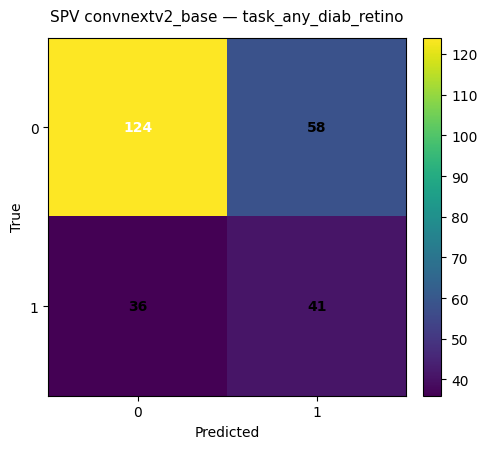

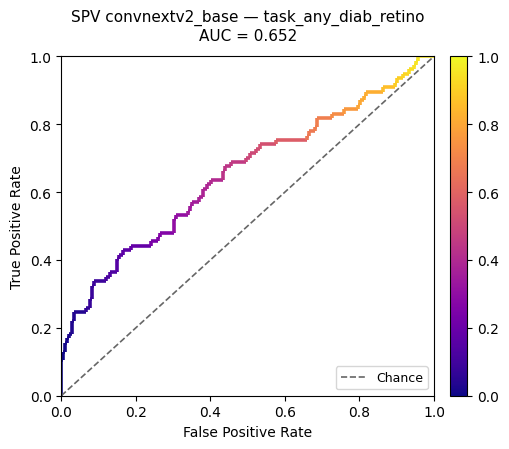


Embedding 2/7: dinov3_convnext_base
  [build_spv] 42 patients had only one eye — filled with copy
  [build_spv] 9 patients had only one eye — filled with copy
  Embed dim: 1024 → SPV dim: 3072 (3×1024)
  Train: 1028 patients | Test: 259 patients
  Class dist (train): {np.int64(0): np.int64(710), np.int64(1): np.int64(318)}
  PCA: 3072 → 128 (91.5% variance)
  Weights: mode=manual, map={0: 1.0, 1: 1.6}
  MLP: (256, 128), alpha=0.03, lr=0.0005, schedule=cosine
  Best epoch: 66
  Threshold (sweep): 0.397

  Patient-Level: F1=0.470  Prec=0.438  Rec=0.506  BalAcc=0.616  AUC=0.637  (259 pts)
              precision    recall  f1-score   support

           0      0.776     0.725     0.750       182
           1      0.438     0.506     0.470        77

    accuracy                          0.660       259
   macro avg      0.607     0.616     0.610       259
weighted avg      0.676     0.660     0.667       259



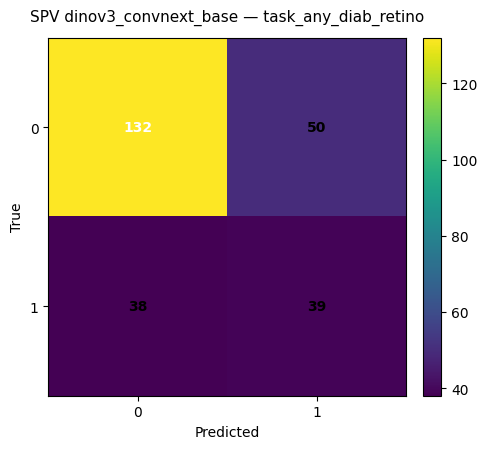

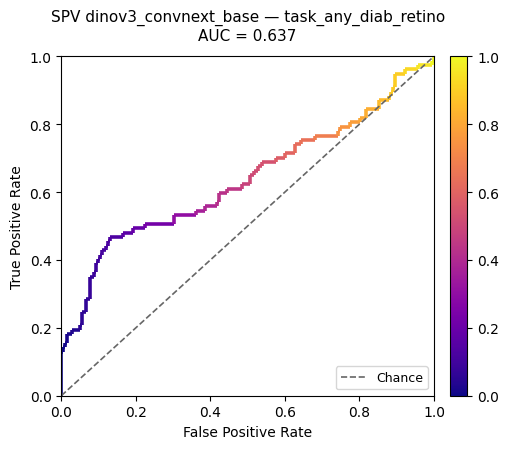


Embedding 3/7: dinov3_vitb16
  [build_spv] 42 patients had only one eye — filled with copy
  [build_spv] 9 patients had only one eye — filled with copy
  Embed dim: 768 → SPV dim: 2304 (3×768)
  Train: 1028 patients | Test: 259 patients
  Class dist (train): {np.int64(0): np.int64(710), np.int64(1): np.int64(318)}
  PCA: 2304 → 128 (81.3% variance)
  Weights: mode=manual, map={0: 1.0, 1: 6.5}
  MLP: (256, 128), alpha=0.06, lr=0.0005, schedule=cosine
  Best epoch: 40
  Threshold (sweep): 0.681

  Patient-Level: F1=0.506  Prec=0.472  Rec=0.545  BalAcc=0.644  AUC=0.715  (259 pts)
              precision    recall  f1-score   support

           0      0.794     0.742     0.767       182
           1      0.472     0.545     0.506        77

    accuracy                          0.683       259
   macro avg      0.633     0.644     0.637       259
weighted avg      0.698     0.683     0.689       259



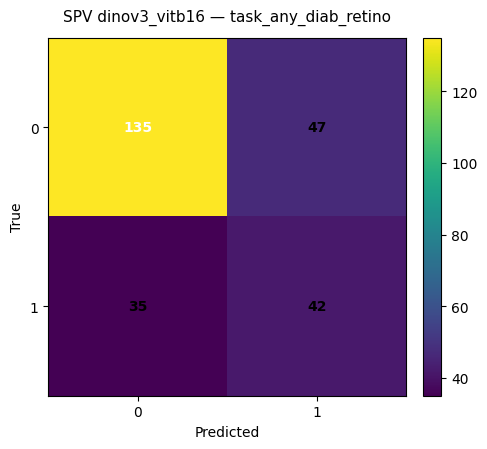

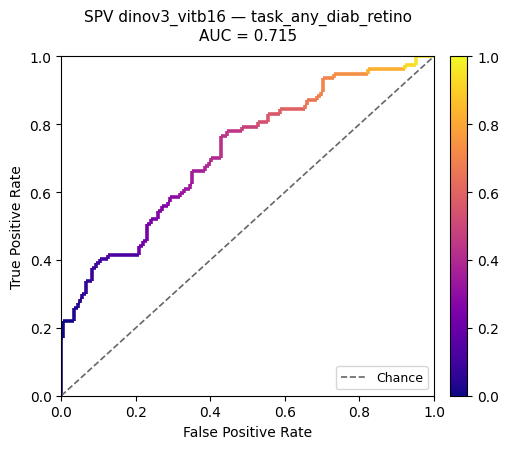


Embedding 4/7: RETFound_dinov2_shanghai
  [build_spv] 42 patients had only one eye — filled with copy
  [build_spv] 9 patients had only one eye — filled with copy
  Embed dim: 1024 → SPV dim: 3072 (3×1024)
  Train: 1028 patients | Test: 259 patients
  Class dist (train): {np.int64(0): np.int64(710), np.int64(1): np.int64(318)}
  PCA: 3072 → 128 (81.0% variance)
  Weights: mode=manual, map={0: 1.0, 1: 3.0}
  MLP: (256, 128), alpha=0.05, lr=0.0005, schedule=cosine
  Best epoch: 37
  Threshold (sweep): 0.387

  Patient-Level: F1=0.463  Prec=0.349  Rec=0.688  BalAcc=0.572  AUC=0.677  (259 pts)
              precision    recall  f1-score   support

           0      0.776     0.456     0.574       182
           1      0.349     0.688     0.463        77

    accuracy                          0.525       259
   macro avg      0.562     0.572     0.519       259
weighted avg      0.649     0.525     0.541       259



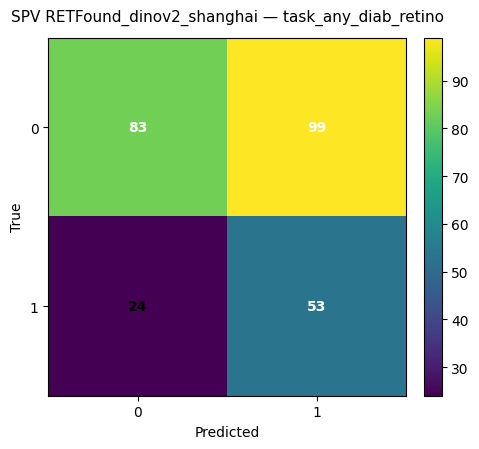

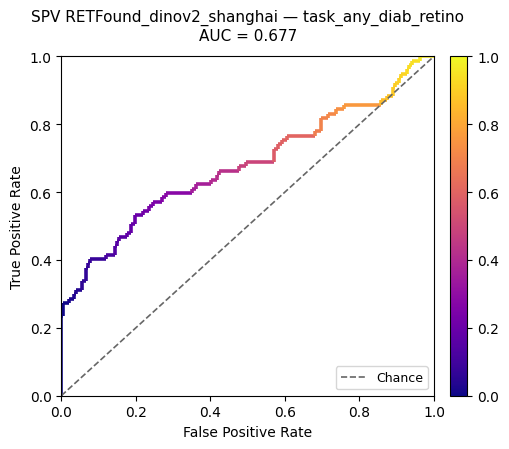


Embedding 5/7: RETFound_mae_natureCFP
  [build_spv] 42 patients had only one eye — filled with copy
  [build_spv] 9 patients had only one eye — filled with copy
  Embed dim: 1024 → SPV dim: 3072 (3×1024)
  Train: 1028 patients | Test: 259 patients
  Class dist (train): {np.int64(0): np.int64(710), np.int64(1): np.int64(318)}
  PCA: 3072 → 128 (89.8% variance)
  Weights: mode=manual, map={0: 1.0, 1: 1.6}
  MLP: (256, 128), alpha=0.03, lr=0.0005, schedule=cosine
  Best epoch: 31
  Threshold (sweep): 0.637

  Patient-Level: F1=0.333  Prec=0.842  Rec=0.208  BalAcc=0.596  AUC=0.638  (259 pts)
              precision    recall  f1-score   support

           0      0.746     0.984     0.848       182
           1      0.842     0.208     0.333        77

    accuracy                          0.753       259
   macro avg      0.794     0.596     0.591       259
weighted avg      0.774     0.753     0.695       259



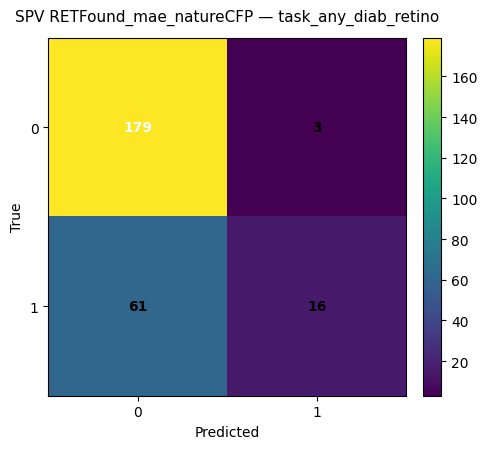

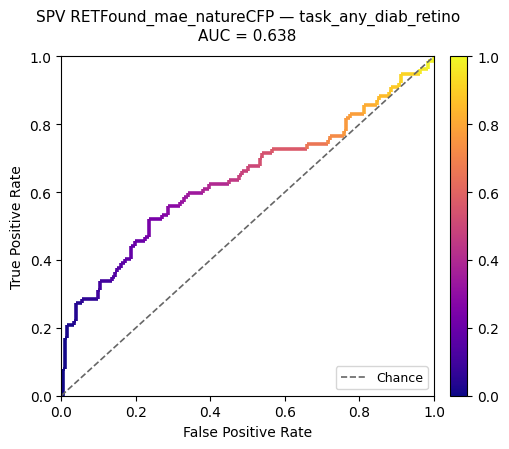


Embedding 6/7: RETFound_mae_shanghai
  [build_spv] 42 patients had only one eye — filled with copy
  [build_spv] 9 patients had only one eye — filled with copy
  Embed dim: 1024 → SPV dim: 3072 (3×1024)
  Train: 1028 patients | Test: 259 patients
  Class dist (train): {np.int64(0): np.int64(710), np.int64(1): np.int64(318)}
  PCA: 3072 → 128 (88.9% variance)
  Weights: mode=manual, map={0: 1.0, 1: 1.0}
  MLP: (256, 128), alpha=0.07, lr=0.0005, schedule=cosine
  Best epoch: 36
  Threshold (sweep): 0.265

  Patient-Level: F1=0.486  Prec=0.380  Rec=0.675  BalAcc=0.604  AUC=0.679  (259 pts)
              precision    recall  f1-score   support

           0      0.795     0.533     0.638       182
           1      0.380     0.675     0.486        77

    accuracy                          0.575       259
   macro avg      0.587     0.604     0.562       259
weighted avg      0.672     0.575     0.593       259



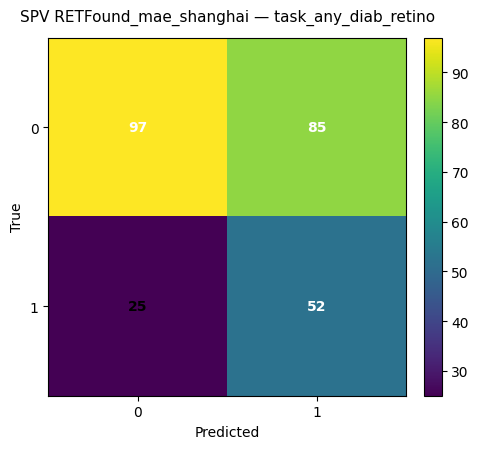

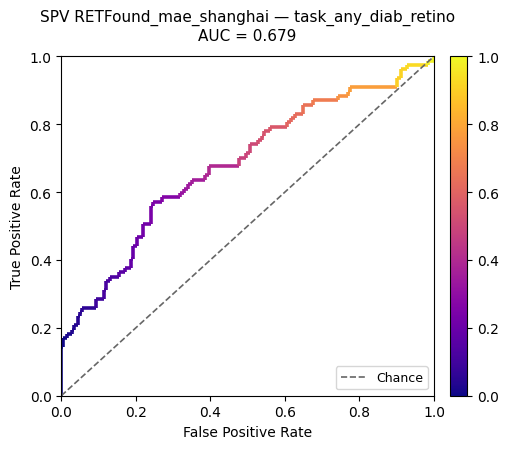


Embedding 7/7: vit_base
  [build_spv] 42 patients had only one eye — filled with copy
  [build_spv] 9 patients had only one eye — filled with copy
  Embed dim: 768 → SPV dim: 2304 (3×768)
  Train: 1028 patients | Test: 259 patients
  Class dist (train): {np.int64(0): np.int64(710), np.int64(1): np.int64(318)}
  PCA: 2304 → 128 (85.6% variance)
  Weights: mode=manual, map={0: 1.0, 1: 2.6}
  MLP: (256, 128), alpha=0.05, lr=0.0005, schedule=cosine
  Best epoch: 44
  Threshold (sweep): 0.627

  Patient-Level: F1=0.390  Prec=0.522  Rec=0.312  BalAcc=0.595  AUC=0.594  (259 pts)
              precision    recall  f1-score   support

           0      0.751     0.879     0.810       182
           1      0.522     0.312     0.390        77

    accuracy                          0.710       259
   macro avg      0.636     0.595     0.600       259
weighted avg      0.683     0.710     0.685       259



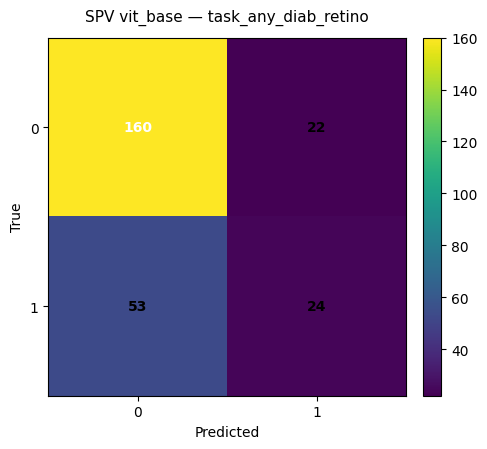

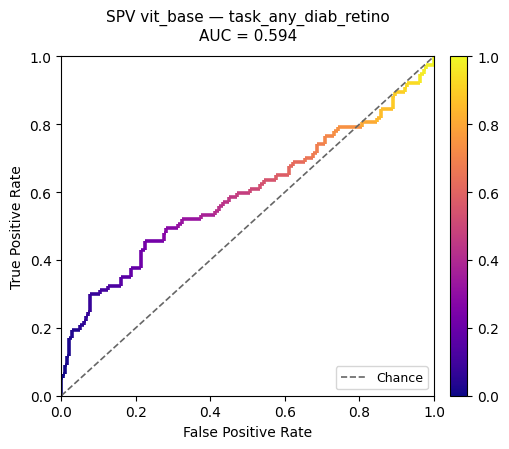


Single-model evaluation complete!


In [6]:
# ═══════════════════════════════════════════════════════════════════════════════
# Cell 6 — Train & Evaluate: Single Model per Embedding
# ═══════════════════════════════════════════════════════════════════════════════

all_results = []

print(f"Evaluating {len(embedding_files)} embeddings with structured patient vectors")
print(f"PCA: 3×D → {PCA_N_COMPONENTS}")
print(f"MLP: cosine LR schedule, per-embedding alpha overrides")
print(f"Weights: from sweep | Threshold: from sweep")

for emb_idx, emb_path in enumerate(embedding_files):
    emb_stem = emb_path.stem
    short_name = emb_stem.replace("Embeddings_", "").replace("mbrset_", "").replace("_mbrset", "")
    print(f"\n{'='*80}")
    print(f"Embedding {emb_idx+1}/{len(embedding_files)}: {short_name}")
    print(f"{'='*80}")
    
    # Load
    ds = load_retina_embeddings_dataset(
        dataset=DATASET_NAME, embeddings_csv_path=emb_path,
        labels_csv_path=labels_path, view=VIEW,
    )
    all_df = ds.df.copy()
    all_df['patient_id'] = all_df['patient_id'].astype(str)
    
    task = BINARY_TASKS[0]
    display_task = BINARY_TASK_MAP.get(task, task)
    
    train_imgs = all_df[all_df['patient_id'].isin(train_patient_ids)].dropna(subset=[task]).copy()
    test_imgs = all_df[all_df['patient_id'].isin(test_patient_ids)].dropna(subset=[task]).copy()
    
    if train_imgs.empty or test_imgs.empty:
        print("  Skipping: insufficient data")
        continue
    
    # Build structured patient vectors
    train_pids, X_train, y_train = build_structured_patient_vectors(
        train_imgs, ds.feature_cols, label_col=task
    )
    test_pids, X_test, y_test = build_structured_patient_vectors(
        test_imgs, ds.feature_cols, label_col=task
    )
    
    embed_dim = len(ds.feature_cols)
    spv_dim = X_train.shape[1]
    classes, counts = np.unique(y_train, return_counts=True)
    print(f"  Embed dim: {embed_dim} → SPV dim: {spv_dim} (3×{embed_dim})")
    print(f"  Train: {len(y_train)} patients | Test: {len(y_test)} patients")
    print(f"  Class dist (train): {dict(zip(classes.astype(int), counts))}")
    
    # PCA + Scale
    pca = PCA(n_components=PCA_N_COMPONENTS, random_state=RANDOM_SEED)
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)
    var_explained = pca.explained_variance_ratio_.sum()
    print(f"  PCA: {spv_dim} → {PCA_N_COMPONENTS} ({var_explained:.1%} variance)")
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_pca)
    X_test_scaled = scaler.transform(X_test_pca)
    
    # Weight config from sweep
    wt_cfg = WEIGHTING_OVERRIDES.get(emb_stem, {"mode": "balanced"})
    wt_mode = wt_cfg.get("mode", "balanced")
    class_weight_map = compute_class_weight_mapping(
        y_train, mode=wt_mode,
        manual_class_weight=wt_cfg.get("manual"),
        damping_gamma=wt_cfg.get("damping_gamma", 1.0),
    )
    sample_weights_train = compute_sample_weights(y_train, class_weight_map, normalize=True)
    print(f"  Weights: mode={wt_mode}, map={class_weight_map}")
    
    # MLP config
    mlp_cfg = resolve_config(emb_stem)
    print(f"  MLP: {mlp_cfg['hidden_layer_sizes']}, alpha={mlp_cfg['alpha']}, "
          f"lr={mlp_cfg['learning_rate_init']}, schedule={mlp_cfg['lr_schedule']}")
    
    # Internal 85/15 val split for early stopping
    from sklearn.model_selection import train_test_split
    _X_tr, _X_va, _y_tr, _y_va, _idx_tr, _idx_va = train_test_split(
        X_train_scaled, y_train, np.arange(len(y_train)),
        test_size=0.15, random_state=RANDOM_SEED, stratify=y_train,
    )
    _sw_tr = compute_sample_weights(_y_tr, class_weight_map, normalize=True)
    _sw_va = compute_sample_weights(_y_va, class_weight_map, normalize=True)
    
    best_model, _best_ep, train_losses, val_losses = train_mlp_with_schedule(
        _X_tr, _y_tr, _X_va, _y_va, mlp_cfg,
        sample_weight_train=_sw_tr, sample_weight_val=_sw_va,
        random_seed=RANDOM_SEED,
    )
    print(f"  Best epoch: {_best_ep}")
    
    # Threshold from sweep or compute on inner val
    thresh_override = THRESHOLD_OVERRIDES.get(emb_stem)
    if thresh_override is not None:
        opt_thresh = float(thresh_override)
        thresh_src = "sweep"
    else:
        _val_proba = best_model.predict_proba(_X_va)[:, 1]
        opt_thresh = find_optimal_threshold(_y_va, _val_proba, method=THRESHOLD_METHOD, grid_size=THRESHOLD_GRID_SIZE)
        thresh_src = f"{THRESHOLD_METHOD}_inner_val"
    print(f"  Threshold ({thresh_src}): {opt_thresh:.3f}")
    
    # ——— TEST evaluation (direct patient-level) ———
    y_proba_test = best_model.predict_proba(X_test_scaled)[:, 1]
    y_pred_test = (y_proba_test >= opt_thresh).astype(int)
    
    accuracy = (y_test == y_pred_test).mean()
    f1 = f1_score(y_test, y_pred_test, zero_division=0)
    precision = precision_score(y_test, y_pred_test, zero_division=0)
    recall = recall_score(y_test, y_pred_test, zero_division=0)
    balanced_acc = balanced_accuracy_score(y_test, y_pred_test)
    fpr, tpr, _ = roc_curve(y_test, y_proba_test)
    auc = roc_auc_score(y_test, y_proba_test)
    
    print(f"\n  Patient-Level: F1={f1:.3f}  Prec={precision:.3f}  Rec={recall:.3f}  "
          f"BalAcc={balanced_acc:.3f}  AUC={auc:.3f}  ({len(y_test)} pts)")
    
    report_text = classification_report(y_test, y_pred_test, digits=3)
    print(report_text)
    
    cm = confusion_matrix(y_test, y_pred_test)
    
    # Save outputs
    out_dir = RESULTS_DIR / f"{emb_idx:02d}_{emb_stem}" / display_task / "mlp"
    out_dir.mkdir(parents=True, exist_ok=True)
    
    (out_dir / "classification_report.txt").write_text(report_text, encoding="utf-8")
    pd.DataFrame(cm).to_csv(out_dir / "confusion_matrix.csv", index=False)
    plot_confusion_matrix(cm, title=f"SPV {short_name} — {display_task}",
                          save_path=out_dir / "confusion_matrix.png" if SAVE_PLOTS else None,
                          show=SHOW_PLOTS)
    
    pd.DataFrame({"fpr": fpr, "tpr": tpr}).to_csv(out_dir / "roc_curve.csv", index=False)
    plot_roc_curve(fpr, tpr, auc, title=f"SPV {short_name} — {display_task}",
                   save_path=out_dir / "roc_curve.png" if SAVE_PLOTS else None,
                   show=SHOW_PLOTS)
    
    # Save patient predictions
    pred_df = pd.DataFrame({
        "patient_id": test_pids, "y_true": y_test,
        "y_pred": y_pred_test, "y_proba": y_proba_test,
    })
    pred_df.to_csv(out_dir / "patient_predictions.csv", index=False)
    
    all_results.append({
        "embedding_idx": emb_idx,
        "embedding": emb_stem,
        "task": display_task,
        "model": "mlp_spv",
        "threshold": float(opt_thresh),
        "threshold_src": thresh_src,
        "n_patients": len(y_test),
        "accuracy": float(accuracy),
        "balanced_accuracy": float(balanced_acc),
        "f1_score": float(f1),
        "precision": float(precision),
        "recall": float(recall),
        "auc": float(auc),
        "spv_dim": spv_dim,
        "pca_variance": float(var_explained),
        "best_epoch": _best_ep,
        "output_dir": str(out_dir),
    })

print(f"\n{'='*80}")
print("Single-model evaluation complete!")
print(f"{'='*80}")

In [7]:
# ═══════════════════════════════════════════════════════════════════════════════
# Cell 7 — Summary Table (Individual SPV Models)
# ═══════════════════════════════════════════════════════════════════════════════

summary_df = pd.DataFrame(all_results)
summary_df = summary_df.sort_values("f1_score", ascending=False).reset_index(drop=True)
summary_df.to_csv(RESULTS_DIR / "summary_individual.csv", index=False)

print("="*100)
print("STRUCTURED PATIENT VECTOR — Individual Embedding Results")
print("="*100)

display_cols = ["embedding", "f1_score", "precision", "recall", "auc",
                "balanced_accuracy", "threshold", "spv_dim", "pca_variance"]
print(summary_df[display_cols].to_string(index=False))

best = summary_df.iloc[0]
print(f"\nBEST INDIVIDUAL SPV: {best['embedding']}")
print(f"  F1={best['f1_score']:.3f}  Prec={best['precision']:.3f}  Rec={best['recall']:.3f}  AUC={best['auc']:.3f}")

# Comparison with R16b baseline
R16B_F1 = 0.658
print(f"\nR16b baseline F1: {R16B_F1:.3f}")
print(f"Best SPV individual F1: {best['f1_score']:.3f} (Δ = {best['f1_score'] - R16B_F1:+.3f})")

display(summary_df[display_cols])

STRUCTURED PATIENT VECTOR — Individual Embedding Results
                                 embedding  f1_score  precision   recall      auc  balanced_accuracy  threshold  spv_dim  pca_variance
           Embeddings_mbrset_dinov3_vitb16  0.506024   0.471910 0.545455 0.715356           0.643606     0.6813     2304      0.812513
   Embeddings_mbrset_RETFound_mae_shanghai  0.485981   0.379562 0.675325 0.679392           0.604146     0.2648     3072      0.888690
    Embeddings_mbrset_dinov3_convnext_base  0.469880   0.438202 0.506494 0.637220           0.615884     0.3971     3072      0.914661
         Embeddings_convnextv2_base_mbrset  0.465909   0.414141 0.532468 0.652419           0.606893     0.3579     3072      0.842462
Embeddings_mbrset_RETFound_dinov2_shanghai  0.462882   0.348684 0.688312 0.677037           0.572178     0.3873     3072      0.810024
                Embeddings_vit_base_mbrset  0.390244   0.521739 0.311688 0.593835           0.595405     0.6274     2304      0.85560

,embedding,f1_score,precision,recall,auc,balanced_accuracy,threshold,spv_dim,pca_variance
0,Embeddings_mbrset_dinov3_vitb16,0.506024,0.471910,0.545455,0.715356,0.643606,0.6813,2304,0.812513
1,Embeddings_mbrset_RETFound_mae_shanghai,0.485981,0.379562,0.675325,0.679392,0.604146,0.2648,3072,0.888690
2,Embeddings_mbrset_dinov3_convnext_base,0.469880,0.438202,0.506494,0.637220,0.615884,0.3971,3072,0.914661
3,Embeddings_convnextv2_base_mbrset,0.465909,0.414141,0.532468,0.652419,0.606893,0.3579,3072,0.842462
4,Embeddings_mbrset_RETFound_dinov2_shanghai,0.462882,0.348684,0.688312,0.677037,0.572178,0.3873,3072,0.810024
5,Embeddings_vit_base_mbrset,0.390244,0.521739,0.311688,0.593835,0.595405,0.6274,2304,0.855609
6,Embeddings_mbrset_RETFound_mae_natureCFP,0.333333,0.842105,0.207792,0.638362,0.595654,0.6372,3072,0.897731


## 7b. Diagnosis & Fix: Block-wise PCA

**Problem**: A single PCA on the 3072-D concatenated vector kills the difference signal.
- `|left - right|` has tiny variance (same-eye cosine similarity ≈ 0.89)
- PCA eigenvectors are dominated by the mean-embedding variance
- Result: the asymmetry signal — the whole point of Strategy 2 — gets projected to zero

**Fix**: Apply PCA **independently** to each structural block:
- `left_emb`  → PCA → 48 components
- `right_emb` → PCA → 48 components  
- `|left - right|` → PCA → 32 components (smaller because diff is lower-rank)
- Concatenate → 128-D total

This preserves each block's own principal subspace. The diff block
gets its own eigenvectors that capture asymmetry patterns, not raw intensity.

RE-EVALUATION WITH BLOCK-WISE PCA
  Left: 48  |  Right: 48  |  Diff: 32  |  Total: 128

--- convnextv2_base ---
  [build_spv] 42 patients had only one eye — filled with copy
  [build_spv] 9 patients had only one eye — filled with copy
  Block PCA variance — Left: 88.9%  Right: 89.0%  Diff: 39.9%
  F1=0.491  Prec=0.456  Rec=0.532  AUC=0.689  BalAcc=0.632  (ep=39)


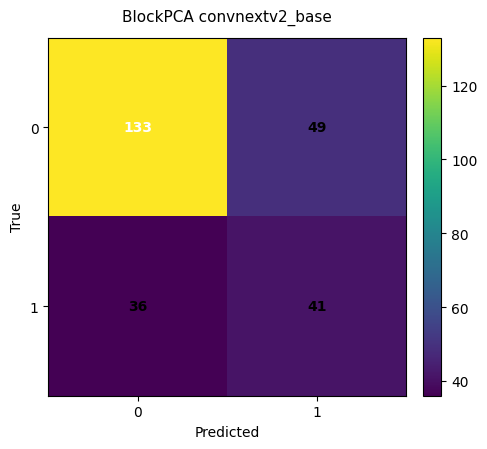

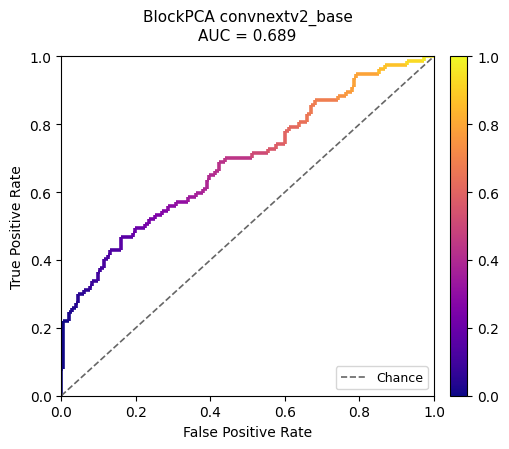


--- dinov3_convnext_base ---
  [build_spv] 42 patients had only one eye — filled with copy
  [build_spv] 9 patients had only one eye — filled with copy
  Block PCA variance — Left: 95.3%  Right: 95.2%  Diff: 64.3%
  F1=0.494  Prec=0.452  Rec=0.545  AUC=0.660  BalAcc=0.633  (ep=42)


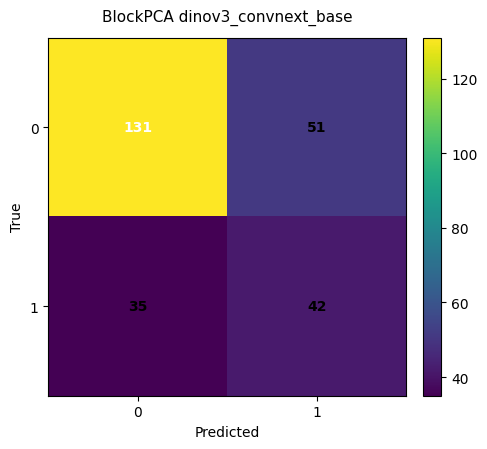

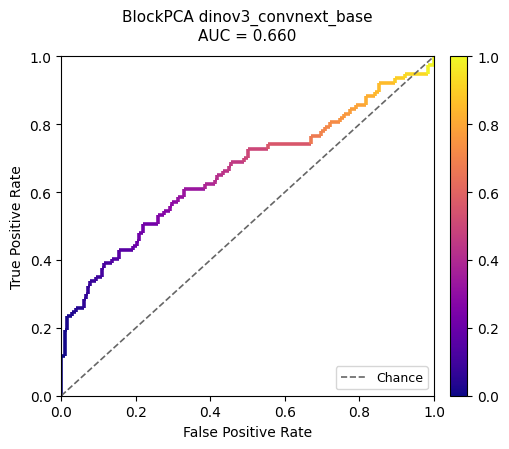


--- dinov3_vitb16 ---
  [build_spv] 42 patients had only one eye — filled with copy
  [build_spv] 9 patients had only one eye — filled with copy
  Block PCA variance — Left: 85.4%  Right: 85.2%  Diff: 35.2%
  F1=0.494  Prec=0.471  Rec=0.519  AUC=0.702  BalAcc=0.636  (ep=28)


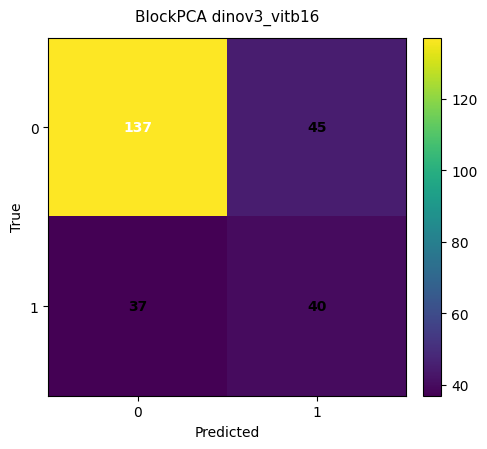

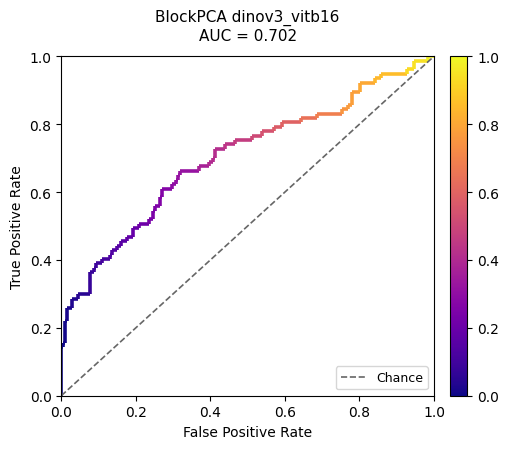


--- RETFound_dinov2_shanghai ---
  [build_spv] 42 patients had only one eye — filled with copy
  [build_spv] 9 patients had only one eye — filled with copy
  Block PCA variance — Left: 86.2%  Right: 86.3%  Diff: 35.5%
  F1=0.515  Prec=0.421  Rec=0.662  AUC=0.712  BalAcc=0.639  (ep=41)


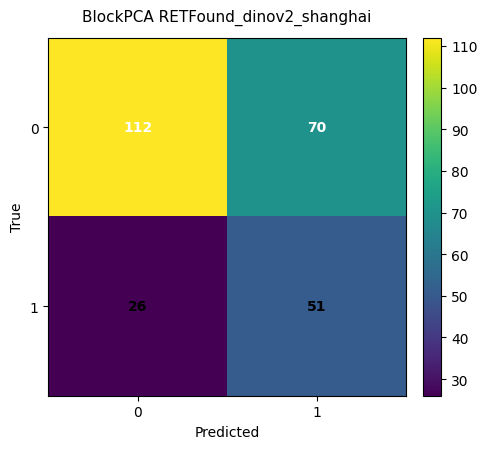

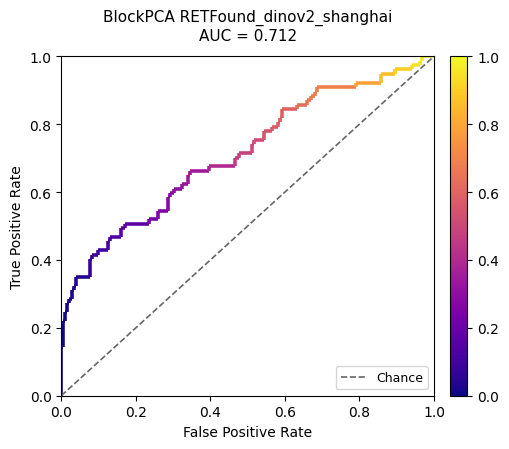


--- RETFound_mae_natureCFP ---
  [build_spv] 42 patients had only one eye — filled with copy
  [build_spv] 9 patients had only one eye — filled with copy
  Block PCA variance — Left: 93.5%  Right: 93.5%  Diff: 56.5%
  F1=0.415  Prec=0.759  Rec=0.286  AUC=0.676  BalAcc=0.624  (ep=33)


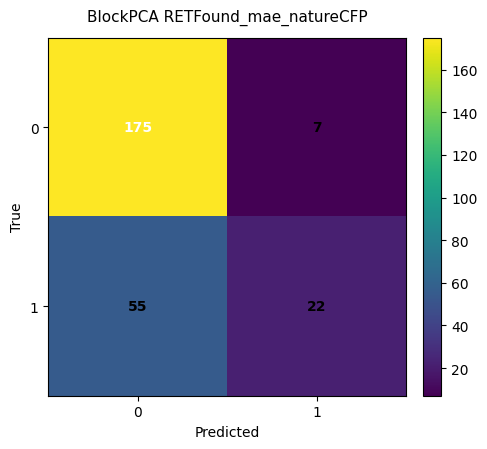

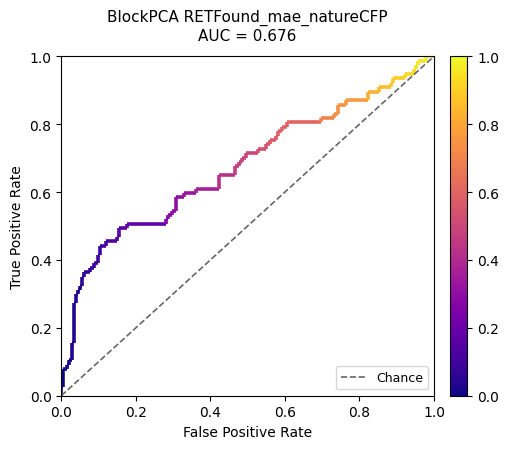


--- RETFound_mae_shanghai ---
  [build_spv] 42 patients had only one eye — filled with copy
  [build_spv] 9 patients had only one eye — filled with copy
  Block PCA variance — Left: 92.3%  Right: 92.2%  Diff: 58.7%
  F1=0.457  Prec=0.375  Rec=0.584  AUC=0.620  BalAcc=0.586  (ep=39)


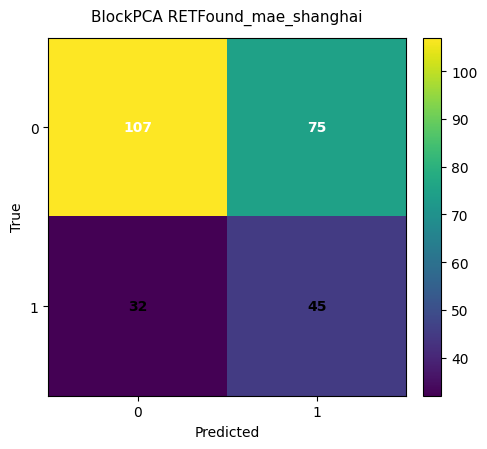

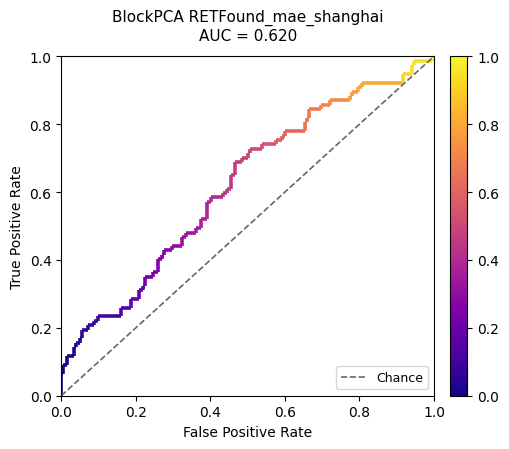


--- vit_base ---
  [build_spv] 42 patients had only one eye — filled with copy
  [build_spv] 9 patients had only one eye — filled with copy
  Block PCA variance — Left: 88.7%  Right: 88.9%  Diff: 53.4%
  F1=0.464  Prec=0.604  Rec=0.377  AUC=0.651  BalAcc=0.636  (ep=42)


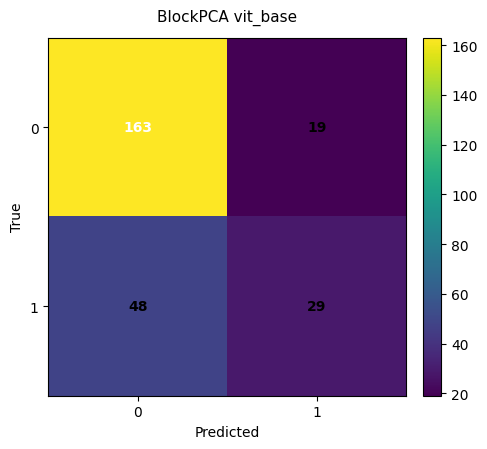

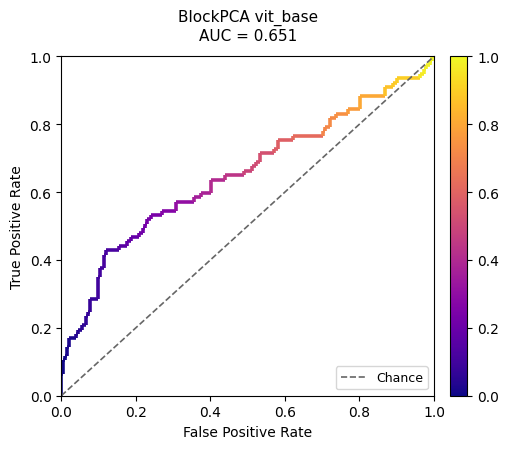


BLOCK-PCA SPV RESULTS (sorted by F1)


,embedding,f1_score,precision,recall,auc,balanced_accuracy,var_left,var_right,var_diff
3,Embeddings_mbrset_RETFound_dinov2_shanghai,0.515152,0.421488,0.662338,0.712359,0.638861,0.862101,0.862547,0.355153
1,Embeddings_mbrset_dinov3_convnext_base,0.494118,0.451613,0.545455,0.660126,0.632617,0.952691,0.951770,0.642592
2,Embeddings_mbrset_dinov3_vitb16,0.493827,0.470588,0.519481,0.702226,0.636114,0.854081,0.851910,0.352431
0,Embeddings_convnextv2_base_mbrset,0.491018,0.455556,0.532468,0.688740,0.631618,0.889193,0.890146,0.398877
6,Embeddings_vit_base_mbrset,0.464000,0.604167,0.376623,0.650921,0.636114,0.887479,0.889156,0.534465
5,Embeddings_mbrset_RETFound_mae_shanghai,0.456853,0.375000,0.584416,0.620308,0.586164,0.922658,0.921922,0.586755
4,Embeddings_mbrset_RETFound_mae_natureCFP,0.415094,0.758621,0.285714,0.675753,0.623626,0.934521,0.934703,0.565472



Best Block-PCA: Embeddings_mbrset_RETFound_dinov2_shanghai  F1=0.515
vs Single-PCA best: 0.506
vs R16b baseline:   0.658


In [8]:
# ═══════════════════════════════════════════════════════════════════════════════
# Cell 7c — Block-wise PCA + Re-evaluation (The Fix)
# ═══════════════════════════════════════════════════════════════════════════════
# Apply PCA independently to left_emb, right_emb, and |diff| blocks
# so the difference vector gets its own principal subspace.

BLOCK_PCA_LEFT = 48
BLOCK_PCA_RIGHT = 48
BLOCK_PCA_DIFF = 32
TOTAL_PCA = BLOCK_PCA_LEFT + BLOCK_PCA_RIGHT + BLOCK_PCA_DIFF  # 128

def block_pca_transform(X_train_spv, X_test_spv, embed_dim):
    """Apply PCA separately to left, right, and diff blocks of the SPV."""
    # Split into blocks
    left_tr = X_train_spv[:, :embed_dim]
    right_tr = X_train_spv[:, embed_dim:2*embed_dim]
    diff_tr = X_train_spv[:, 2*embed_dim:]
    
    left_te = X_test_spv[:, :embed_dim]
    right_te = X_test_spv[:, embed_dim:2*embed_dim]
    diff_te = X_test_spv[:, 2*embed_dim:]

    # PCA per block
    pca_left = PCA(n_components=BLOCK_PCA_LEFT, random_state=RANDOM_SEED)
    pca_right = PCA(n_components=BLOCK_PCA_RIGHT, random_state=RANDOM_SEED)
    pca_diff = PCA(n_components=BLOCK_PCA_DIFF, random_state=RANDOM_SEED)

    left_tr_pca = pca_left.fit_transform(left_tr)
    left_te_pca = pca_left.transform(left_te)

    right_tr_pca = pca_right.fit_transform(right_tr)
    right_te_pca = pca_right.transform(right_te)

    diff_tr_pca = pca_diff.fit_transform(diff_tr)
    diff_te_pca = pca_diff.transform(diff_te)

    # Concatenate
    X_train_out = np.hstack([left_tr_pca, right_tr_pca, diff_tr_pca])
    X_test_out = np.hstack([left_te_pca, right_te_pca, diff_te_pca])

    var_info = {
        "left": pca_left.explained_variance_ratio_.sum(),
        "right": pca_right.explained_variance_ratio_.sum(),
        "diff": pca_diff.explained_variance_ratio_.sum(),
    }
    return X_train_out, X_test_out, var_info


# ═══════════════════════════════════════════════════════════════════════════════
# Re-run evaluation with block-wise PCA
# ═══════════════════════════════════════════════════════════════════════════════
all_results_blockpca = []

print(f"{'='*80}")
print(f"RE-EVALUATION WITH BLOCK-WISE PCA")
print(f"  Left: {BLOCK_PCA_LEFT}  |  Right: {BLOCK_PCA_RIGHT}  |  Diff: {BLOCK_PCA_DIFF}  |  Total: {TOTAL_PCA}")
print(f"{'='*80}")

for emb_idx, emb_path in enumerate(embedding_files):
    emb_stem = emb_path.stem
    short_name = emb_stem.replace("Embeddings_", "").replace("mbrset_", "").replace("_mbrset", "")
    print(f"\n--- {short_name} ---")

    ds = load_retina_embeddings_dataset(
        dataset=DATASET_NAME, embeddings_csv_path=emb_path,
        labels_csv_path=labels_path, view=VIEW,
    )
    all_df = ds.df.copy()
    all_df['patient_id'] = all_df['patient_id'].astype(str)

    task = BINARY_TASKS[0]
    display_task = BINARY_TASK_MAP.get(task, task)

    train_imgs = all_df[all_df['patient_id'].isin(train_patient_ids)].dropna(subset=[task]).copy()
    test_imgs = all_df[all_df['patient_id'].isin(test_patient_ids)].dropna(subset=[task]).copy()

    train_pids, X_train, y_train = build_structured_patient_vectors(
        train_imgs, ds.feature_cols, label_col=task
    )
    test_pids, X_test, y_test = build_structured_patient_vectors(
        test_imgs, ds.feature_cols, label_col=task
    )

    embed_dim = len(ds.feature_cols)

    # Block-wise PCA
    X_train_pca, X_test_pca, var_info = block_pca_transform(X_train, X_test, embed_dim)
    print(f"  Block PCA variance — Left: {var_info['left']:.1%}  Right: {var_info['right']:.1%}  Diff: {var_info['diff']:.1%}")

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_pca)
    X_test_scaled = scaler.transform(X_test_pca)

    # Weight config from sweep
    wt_cfg = WEIGHTING_OVERRIDES.get(emb_stem, {"mode": "balanced"})
    wt_mode = wt_cfg.get("mode", "balanced")
    class_weight_map = compute_class_weight_mapping(
        y_train, mode=wt_mode,
        manual_class_weight=wt_cfg.get("manual"),
        damping_gamma=wt_cfg.get("damping_gamma", 1.0),
    )
    sample_weights_train = compute_sample_weights(y_train, class_weight_map, normalize=True)

    mlp_cfg = resolve_config(emb_stem)

    # Internal 85/15 val split
    from sklearn.model_selection import train_test_split
    _X_tr, _X_va, _y_tr, _y_va = train_test_split(
        X_train_scaled, y_train,
        test_size=0.15, random_state=RANDOM_SEED, stratify=y_train,
    )
    _sw_tr = compute_sample_weights(_y_tr, class_weight_map, normalize=True)
    _sw_va = compute_sample_weights(_y_va, class_weight_map, normalize=True)

    best_model, _best_ep, _, _ = train_mlp_with_schedule(
        _X_tr, _y_tr, _X_va, _y_va, mlp_cfg,
        sample_weight_train=_sw_tr, sample_weight_val=_sw_va,
        random_seed=RANDOM_SEED,
    )

    # Threshold from sweep or inner val
    thresh_override = THRESHOLD_OVERRIDES.get(emb_stem)
    if thresh_override is not None:
        opt_thresh = float(thresh_override)
        thresh_src = "sweep"
    else:
        _val_proba = best_model.predict_proba(_X_va)[:, 1]
        opt_thresh = find_optimal_threshold(_y_va, _val_proba, method=THRESHOLD_METHOD, grid_size=THRESHOLD_GRID_SIZE)
        thresh_src = f"{THRESHOLD_METHOD}_inner_val"

    # Test evaluation
    y_proba_test = best_model.predict_proba(X_test_scaled)[:, 1]
    y_pred_test = (y_proba_test >= opt_thresh).astype(int)

    f1 = f1_score(y_test, y_pred_test, zero_division=0)
    precision = precision_score(y_test, y_pred_test, zero_division=0)
    recall = recall_score(y_test, y_pred_test, zero_division=0)
    auc = roc_auc_score(y_test, y_proba_test)
    balanced_acc = balanced_accuracy_score(y_test, y_pred_test)

    print(f"  F1={f1:.3f}  Prec={precision:.3f}  Rec={recall:.3f}  AUC={auc:.3f}  BalAcc={balanced_acc:.3f}  (ep={_best_ep})")

    # Save
    out_dir = RESULTS_DIR / f"{emb_idx:02d}_{emb_stem}" / display_task / "mlp_blockpca"
    out_dir.mkdir(parents=True, exist_ok=True)

    cm = confusion_matrix(y_test, y_pred_test)
    report = classification_report(y_test, y_pred_test, digits=3)
    (out_dir / "classification_report.txt").write_text(report, encoding="utf-8")

    fpr, tpr, _ = roc_curve(y_test, y_proba_test)
    plot_confusion_matrix(cm, f"BlockPCA {short_name}",
                          save_path=out_dir / "confusion_matrix.png" if SAVE_PLOTS else None, show=SHOW_PLOTS)
    plot_roc_curve(fpr, tpr, auc, f"BlockPCA {short_name}",
                   save_path=out_dir / "roc_curve.png" if SAVE_PLOTS else None, show=SHOW_PLOTS)

    all_results_blockpca.append({
        "embedding": emb_stem,
        "f1_score": float(f1), "precision": float(precision), "recall": float(recall),
        "auc": float(auc), "balanced_accuracy": float(balanced_acc),
        "threshold": float(opt_thresh), "best_epoch": _best_ep,
        "var_left": var_info["left"], "var_right": var_info["right"], "var_diff": var_info["diff"],
    })

# Summary
bp_df = pd.DataFrame(all_results_blockpca).sort_values("f1_score", ascending=False)
bp_df.to_csv(RESULTS_DIR / "summary_blockpca.csv", index=False)

print(f"\n{'='*80}")
print("BLOCK-PCA SPV RESULTS (sorted by F1)")
print(f"{'='*80}")
display(bp_df[["embedding", "f1_score", "precision", "recall", "auc", "balanced_accuracy",
               "var_left", "var_right", "var_diff"]])

best_bp = bp_df.iloc[0]
print(f"\nBest Block-PCA: {best_bp['embedding']}  F1={best_bp['f1_score']:.3f}")
print(f"vs Single-PCA best: {summary_df.iloc[0]['f1_score']:.3f}")
print(f"vs R16b baseline:   0.658")

In [9]:
# ═══════════════════════════════════════════════════════════════════════════════
# Cell 7d — LGBM on SPV (no PCA needed — trees handle high-D natively)
# ═══════════════════════════════════════════════════════════════════════════════
# Last attempt to rescue Strategy 2: LightGBM handles small n better than MLP
# and doesn't need PCA. Also try LGBM on block-PCA features.

from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold

all_results_lgbm = []

print(f"{'='*80}")
print(f"LGBM ON RAW STRUCTURED PATIENT VECTORS  (no PCA)")
print(f"{'='*80}")

for emb_idx, emb_path in enumerate(embedding_files):
    emb_stem = emb_path.stem
    short_name = emb_stem.replace("Embeddings_", "").replace("mbrset_", "").replace("_mbrset", "")
    print(f"\n--- {short_name} ---")

    ds = load_retina_embeddings_dataset(
        dataset=DATASET_NAME, embeddings_csv_path=emb_path,
        labels_csv_path=labels_path, view=VIEW,
    )
    all_df = ds.df.copy()
    all_df['patient_id'] = all_df['patient_id'].astype(str)

    task = BINARY_TASKS[0]
    display_task = BINARY_TASK_MAP.get(task, task)

    train_imgs = all_df[all_df['patient_id'].isin(train_patient_ids)].dropna(subset=[task]).copy()
    test_imgs  = all_df[all_df['patient_id'].isin(test_patient_ids)].dropna(subset=[task]).copy()

    train_pids, X_train, y_train = build_structured_patient_vectors(
        train_imgs, ds.feature_cols, label_col=task
    )
    test_pids, X_test, y_test = build_structured_patient_vectors(
        test_imgs, ds.feature_cols, label_col=task
    )

    embed_dim = len(ds.feature_cols)

    # Weight config
    wt_cfg = WEIGHTING_OVERRIDES.get(emb_stem, {"mode": "balanced"})
    n_pos = int(y_train.sum())
    n_neg = len(y_train) - n_pos
    scale_pos = n_neg / max(n_pos, 1)
    
    # ─── LGBM on raw SPV (no PCA) ───────────────────────────────────────
    lgbm_raw = LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        num_leaves=31,
        min_child_samples=20,
        subsample=0.8,
        colsample_bytree=0.3,   # aggressive subsampling for high-D
        scale_pos_weight=scale_pos,
        random_state=RANDOM_SEED,
        verbose=-1,
        n_jobs=-1,
    )
    lgbm_raw.fit(X_train, y_train)
    
    y_proba_raw = lgbm_raw.predict_proba(X_test)[:, 1]
    
    # Threshold optimisation on inner val
    from sklearn.model_selection import train_test_split
    _X_tr, _X_va, _y_tr, _y_va = train_test_split(
        X_train, y_train, test_size=0.15, random_state=RANDOM_SEED, stratify=y_train
    )
    lgbm_inner = LGBMClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=5, num_leaves=31,
        min_child_samples=20, subsample=0.8, colsample_bytree=0.3,
        scale_pos_weight=scale_pos, random_state=RANDOM_SEED, verbose=-1, n_jobs=-1,
    )
    lgbm_inner.fit(_X_tr, _y_tr)
    _va_proba = lgbm_inner.predict_proba(_X_va)[:, 1]
    opt_thresh = find_optimal_threshold(_y_va, _va_proba, method=THRESHOLD_METHOD, grid_size=THRESHOLD_GRID_SIZE)
    
    y_pred_raw = (y_proba_raw >= opt_thresh).astype(int)
    
    f1_raw = f1_score(y_test, y_pred_raw, zero_division=0)
    prec_raw = precision_score(y_test, y_pred_raw, zero_division=0)
    rec_raw = recall_score(y_test, y_pred_raw, zero_division=0)
    auc_raw = roc_auc_score(y_test, y_proba_raw)
    ba_raw = balanced_accuracy_score(y_test, y_pred_raw)
    
    print(f"  LGBM-Raw:  F1={f1_raw:.3f}  Prec={prec_raw:.3f}  Rec={rec_raw:.3f}  AUC={auc_raw:.3f}  t={opt_thresh:.2f}")

    # ─── LGBM on block-PCA SPV ──────────────────────────────────────────
    X_tr_bpca, X_te_bpca, _ = block_pca_transform(X_train, X_test, embed_dim)
    
    lgbm_bpca = LGBMClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=5, num_leaves=31,
        min_child_samples=20, subsample=0.8, colsample_bytree=0.5,
        scale_pos_weight=scale_pos, random_state=RANDOM_SEED, verbose=-1, n_jobs=-1,
    )
    lgbm_bpca.fit(X_tr_bpca, y_train)
    y_proba_bpca = lgbm_bpca.predict_proba(X_te_bpca)[:, 1]
    
    _Xb_tr, _Xb_va, _yb_tr, _yb_va = train_test_split(
        X_tr_bpca, y_train, test_size=0.15, random_state=RANDOM_SEED, stratify=y_train
    )
    lgbm_bpca_inner = LGBMClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=5, num_leaves=31,
        min_child_samples=20, subsample=0.8, colsample_bytree=0.5,
        scale_pos_weight=scale_pos, random_state=RANDOM_SEED, verbose=-1, n_jobs=-1,
    )
    lgbm_bpca_inner.fit(_Xb_tr, _yb_tr)
    _vab_proba = lgbm_bpca_inner.predict_proba(_Xb_va)[:, 1]
    opt_thresh_bpca = find_optimal_threshold(_yb_va, _vab_proba, method=THRESHOLD_METHOD, grid_size=THRESHOLD_GRID_SIZE)
    
    y_pred_bpca = (y_proba_bpca >= opt_thresh_bpca).astype(int)
    
    f1_bpca = f1_score(y_test, y_pred_bpca, zero_division=0)
    prec_bpca = precision_score(y_test, y_pred_bpca, zero_division=0)
    rec_bpca = recall_score(y_test, y_pred_bpca, zero_division=0)
    auc_bpca = roc_auc_score(y_test, y_proba_bpca)
    ba_bpca = balanced_accuracy_score(y_test, y_pred_bpca)
    
    print(f"  LGBM-BPCA: F1={f1_bpca:.3f}  Prec={prec_bpca:.3f}  Rec={rec_bpca:.3f}  AUC={auc_bpca:.3f}  t={opt_thresh_bpca:.2f}")

    # Save both results
    out_dir_lgbm = RESULTS_DIR / f"{emb_idx:02d}_{emb_stem}" / display_task / "lgbm_raw_spv"
    out_dir_lgbm.mkdir(parents=True, exist_ok=True)
    cm_raw = confusion_matrix(y_test, y_pred_raw)
    report_raw = classification_report(y_test, y_pred_raw, digits=3)
    (out_dir_lgbm / "classification_report.txt").write_text(report_raw, encoding="utf-8")
    
    all_results_lgbm.append({
        "embedding": emb_stem,
        "method": "LGBM_raw_SPV",
        "f1_score": f1_raw, "precision": prec_raw, "recall": rec_raw,
        "auc": auc_raw, "balanced_accuracy": ba_raw, "threshold": opt_thresh,
    })
    all_results_lgbm.append({
        "embedding": emb_stem,
        "method": "LGBM_blockPCA_SPV",
        "f1_score": f1_bpca, "precision": prec_bpca, "recall": rec_bpca,
        "auc": auc_bpca, "balanced_accuracy": ba_bpca, "threshold": opt_thresh_bpca,
    })

lgbm_df = pd.DataFrame(all_results_lgbm).sort_values("f1_score", ascending=False)
lgbm_df.to_csv(RESULTS_DIR / "summary_lgbm_spv.csv", index=False)

print(f"\n{'='*80}")
print("ALL LGBM SPV RESULTS (sorted by F1)")
print(f"{'='*80}")
display(lgbm_df[["embedding", "method", "f1_score", "precision", "recall", "auc", "balanced_accuracy"]])

best_lgbm = lgbm_df.iloc[0]
print(f"\nBest LGBM SPV: {best_lgbm['method']} ({best_lgbm['embedding']})  F1={best_lgbm['f1_score']:.3f}")
print(f"vs MLP Block-PCA best: {bp_df.iloc[0]['f1_score']:.3f}")
print(f"vs MLP Single-PCA best: {summary_df.iloc[0]['f1_score']:.3f}")
print(f"vs R16b baseline:       0.658")

LGBM ON RAW STRUCTURED PATIENT VECTORS  (no PCA)

--- convnextv2_base ---
  [build_spv] 42 patients had only one eye — filled with copy
  [build_spv] 9 patients had only one eye — filled with copy
  LGBM-Raw:  F1=0.534  Prec=0.426  Rec=0.714  AUC=0.727  t=0.08
  LGBM-BPCA: F1=0.440  Prec=0.484  Rec=0.403  AUC=0.675  t=0.35

--- dinov3_convnext_base ---
  [build_spv] 42 patients had only one eye — filled with copy
  [build_spv] 9 patients had only one eye — filled with copy
  LGBM-Raw:  F1=0.476  Prec=0.440  Rec=0.519  AUC=0.687  t=0.21
  LGBM-BPCA: F1=0.485  Prec=0.455  Rec=0.519  AUC=0.698  t=0.30

--- dinov3_vitb16 ---
  [build_spv] 42 patients had only one eye — filled with copy
  [build_spv] 9 patients had only one eye — filled with copy
  LGBM-Raw:  F1=0.588  Prec=0.678  Rec=0.519  AUC=0.755  t=0.36
  LGBM-BPCA: F1=0.532  Prec=0.450  Rec=0.649  AUC=0.728  t=0.22

--- RETFound_dinov2_shanghai ---
  [build_spv] 42 patients had only one eye — filled with copy
  [build_spv] 9 patients

,embedding,method,f1_score,precision,recall,auc,balanced_accuracy
4,Embeddings_mbrset_dinov3_vitb16,LGBM_raw_SPV,0.588235,0.677966,0.519481,0.755173,0.707542
7,Embeddings_mbrset_RETFound_dinov2_shanghai,LGBM_blockPCA_SPV,0.561983,0.772727,0.441558,0.751820,0.693307
0,Embeddings_convnextv2_base_mbrset,LGBM_raw_SPV,0.533981,0.426357,0.714286,0.727415,0.653846
5,Embeddings_mbrset_dinov3_vitb16,LGBM_blockPCA_SPV,0.531915,0.450450,0.649351,0.728200,0.657093
12,Embeddings_vit_base_mbrset,LGBM_raw_SPV,0.511848,0.402985,0.701299,0.684815,0.630869
6,Embeddings_mbrset_RETFound_dinov2_shanghai,LGBM_raw_SPV,0.494949,0.404959,0.636364,0.697945,0.620380
3,Embeddings_mbrset_dinov3_convnext_base,LGBM_blockPCA_SPV,0.484848,0.454545,0.519481,0.697945,0.627872
8,Embeddings_mbrset_RETFound_mae_natureCFP,LGBM_raw_SPV,0.476923,0.338798,0.805195,0.642500,0.570180
2,Embeddings_mbrset_dinov3_convnext_base,LGBM_raw_SPV,0.476190,0.439560,0.519481,0.686599,0.619630
9,Embeddings_mbrset_RETFound_mae_natureCFP,LGBM_blockPCA_SPV,0.474820,0.328358,0.857143,0.611674,0.557692



Best LGBM SPV: LGBM_raw_SPV (Embeddings_mbrset_dinov3_vitb16)  F1=0.588
vs MLP Block-PCA best: 0.515
vs MLP Single-PCA best: 0.506
vs R16b baseline:       0.658


## 8. Bagged SPV Models (5 seeds × 3 architectures)

For each embedding:
- 5 random seeds × 3 MLP architectures = 15 sub-models
- Average predictions across sub-models
- Also train mixup-augmented variants
- Pick best variant by F1 threshold search

In [10]:
# ═══════════════════════════════════════════════════════════════════════════════
# Cell 8 — Bagged SPV Models
# ═══════════════════════════════════════════════════════════════════════════════

BAG_SEEDS = [42, 123, 314, 555, 789]
BAG_ARCHITECTURES = [(512, 256), (384, 192), (256, 128)]
MIXUP_ALPHA = 0.4
BAG_THRESHOLD_FLOOR = 0.20

def mixup_data(X, y, alpha=0.4, seed=42):
    rng = np.random.RandomState(seed)
    n = len(X)
    lam = rng.beta(alpha, alpha, size=n)
    lam = np.maximum(lam, 1 - lam)
    idx = rng.permutation(n)
    X_mix = (lam[:, None] * X + (1 - lam[:, None]) * X[idx])
    y_mix = (lam * y + (1 - lam) * y[idx])
    y_mix_hard = (y_mix >= 0.5).astype(int)
    return np.vstack([X, X_mix]), np.concatenate([y.astype(int), y_mix_hard])

print(f"{'='*80}")
print(f"BAGGED SPV MODELS — {len(BAG_SEEDS)} seeds × {len(BAG_ARCHITECTURES)} archs "
      f"= {len(BAG_SEEDS)*len(BAG_ARCHITECTURES)} sub-models per embedding")
print(f"{'='*80}")

thresholds_grid = np.linspace(0.01, 0.99, THRESHOLD_GRID_SIZE)
thresholds_grid = thresholds_grid[thresholds_grid >= BAG_THRESHOLD_FLOOR]

bagged_results = []

for emb_path in embedding_files:
    emb_stem = emb_path.stem
    short_name = emb_stem.replace("Embeddings_", "").replace("mbrset_", "").replace("_mbrset", "")
    print(f"\n--- {short_name} ---")
    
    ds = load_retina_embeddings_dataset(
        dataset=DATASET_NAME, embeddings_csv_path=emb_path,
        labels_csv_path=labels_path, view=VIEW,
    )
    all_df = ds.df.copy()
    all_df['patient_id'] = all_df['patient_id'].astype(str)
    
    task = BINARY_TASKS[0]
    train_imgs = all_df[all_df['patient_id'].isin(train_patient_ids)].dropna(subset=[task]).copy()
    test_imgs = all_df[all_df['patient_id'].isin(test_patient_ids)].dropna(subset=[task]).copy()
    
    # Build structured patient vectors
    train_pids, X_train, y_train = build_structured_patient_vectors(
        train_imgs, ds.feature_cols, label_col=task
    )
    test_pids, X_test, y_test = build_structured_patient_vectors(
        test_imgs, ds.feature_cols, label_col=task
    )
    
    # PCA + Scale
    pca = PCA(n_components=PCA_N_COMPONENTS, random_state=RANDOM_SEED)
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train_pca)
    X_test_s = scaler.transform(X_test_pca)
    
    # Weight from sweep
    wt_cfg = WEIGHTING_OVERRIDES.get(emb_stem, {"mode": "balanced"})
    cw_map = compute_class_weight_mapping(
        y_train, mode=wt_cfg.get("mode", "balanced"),
        manual_class_weight=wt_cfg.get("manual"),
        damping_gamma=wt_cfg.get("damping_gamma", 1.0),
    )
    
    # Train 15 no-mixup + 15 mixup sub-models
    nomix_probas, mix_probas = [], []
    
    for seed in BAG_SEEDS:
        for arch in BAG_ARCHITECTURES:
            mlp_cfg = resolve_config(emb_stem)
            sw_train = compute_sample_weights(y_train, cw_map, normalize=True)
            
            # No-mixup
            mlp_nomix = MLPClassifier(
                hidden_layer_sizes=arch, alpha=mlp_cfg["alpha"],
                learning_rate_init=mlp_cfg["learning_rate_init"],
                batch_size=mlp_cfg["batch_size"], max_iter=mlp_cfg["max_epochs"],
                early_stopping=True, validation_fraction=0.15,
                n_iter_no_change=mlp_cfg["patience"], random_state=seed,
            )
            safe_fit_with_optional_sample_weight(mlp_nomix, X_train_s, y_train, sample_weight=sw_train)
            nomix_probas.append(mlp_nomix.predict_proba(X_test_s)[:, 1])
            
            # Mixup
            X_mix, y_mix = mixup_data(X_train_s, y_train.astype(np.float64), alpha=MIXUP_ALPHA, seed=seed)
            sw_mix = np.ones(len(y_mix), dtype=np.float32)
            sw_mix[:len(y_train)] = sw_train
            sw_mix[len(y_train):] = np.mean(sw_train)
            
            mlp_mix = MLPClassifier(
                hidden_layer_sizes=arch, alpha=mlp_cfg["alpha"],
                learning_rate_init=mlp_cfg["learning_rate_init"],
                batch_size=mlp_cfg["batch_size"], max_iter=mlp_cfg["max_epochs"],
                early_stopping=True, validation_fraction=0.15,
                n_iter_no_change=mlp_cfg["patience"], random_state=seed,
            )
            safe_fit_with_optional_sample_weight(mlp_mix, X_mix, y_mix, sample_weight=sw_mix)
            mix_probas.append(mlp_mix.predict_proba(X_test_s)[:, 1])
    
    # Average across sub-models
    nomix_avg = np.mean(nomix_probas, axis=0)
    mix_avg = np.mean(mix_probas, axis=0)
    combined_avg = np.mean(nomix_probas + mix_probas, axis=0)
    
    # Find best variant
    variants = {"NoMix": nomix_avg, "Mixup": mix_avg, "Combined": combined_avg}
    best_variant_name, best_variant_f1 = None, -1.0
    best_variant_row = None
    
    for var_name, proba in variants.items():
        best_t, best_f1 = 0.5, -1.0
        for t in thresholds_grid:
            yp = (proba >= t).astype(int)
            f1v = float(f1_score(y_test, yp, zero_division=0))
            if f1v > best_f1:
                best_f1 = f1v
                best_t = float(t)
        
        y_pred = (proba >= best_t).astype(int)
        f1_val = f1_score(y_test, y_pred, zero_division=0)
        prec_val = precision_score(y_test, y_pred, zero_division=0)
        rec_val = recall_score(y_test, y_pred, zero_division=0)
        auc_val = roc_auc_score(y_test, proba) if len(np.unique(y_test)) == 2 else 0.5
        
        if f1_val > best_variant_f1:
            best_variant_f1 = f1_val
            best_variant_name = var_name
            best_variant_row = {
                "embedding": emb_stem,
                "bag_variant": var_name,
                "f1_score": float(f1_val),
                "precision": float(prec_val),
                "recall": float(rec_val),
                "auc": float(auc_val),
                "threshold": float(best_t),
                "n_patients": len(y_test),
            }
    
    # Get single-model baseline
    baseline = [r for r in all_results if r["embedding"] == emb_stem]
    baseline_f1 = baseline[0]["f1_score"] if baseline else 0.0
    best_variant_row["single_f1"] = float(baseline_f1)
    best_variant_row["delta_f1"] = float(best_variant_f1 - baseline_f1)
    
    bagged_results.append(best_variant_row)
    print(f"  Best: {best_variant_name}  F1={best_variant_f1:.3f}  "
          f"P={best_variant_row['precision']:.3f}  R={best_variant_row['recall']:.3f}  "
          f"AUC={best_variant_row['auc']:.3f}  (Δ vs single: {best_variant_row['delta_f1']:+.3f})")

bag_df = pd.DataFrame(bagged_results).sort_values("f1_score", ascending=False)
bag_df.to_csv(RESULTS_DIR / "bagged_spv_results.csv", index=False)

print(f"\n{'='*80}")
print("BAGGED SPV RESULTS (sorted by F1)")
print(f"{'='*80}")
display(bag_df[["embedding", "bag_variant", "f1_score", "precision", "recall",
                "auc", "threshold", "single_f1", "delta_f1"]])

BAGGED SPV MODELS — 5 seeds × 3 archs = 15 sub-models per embedding

--- convnextv2_base ---
  [build_spv] 42 patients had only one eye — filled with copy
  [build_spv] 9 patients had only one eye — filled with copy
  Best: Mixup  F1=0.565  P=0.639  R=0.506  AUC=0.718  (Δ vs single: +0.099)

--- dinov3_convnext_base ---
  [build_spv] 42 patients had only one eye — filled with copy
  [build_spv] 9 patients had only one eye — filled with copy
  Best: NoMix  F1=0.567  P=0.625  R=0.519  AUC=0.691  (Δ vs single: +0.097)

--- dinov3_vitb16 ---
  [build_spv] 42 patients had only one eye — filled with copy
  [build_spv] 9 patients had only one eye — filled with copy
  Best: NoMix  F1=0.551  P=0.485  R=0.636  AUC=0.729  (Δ vs single: +0.045)

--- RETFound_dinov2_shanghai ---
  [build_spv] 42 patients had only one eye — filled with copy
  [build_spv] 9 patients had only one eye — filled with copy
  Best: NoMix  F1=0.597  P=0.642  R=0.558  AUC=0.742  (Δ vs single: +0.134)

--- RETFound_mae_nature

,embedding,bag_variant,f1_score,precision,recall,auc,threshold,single_f1,delta_f1
3,Embeddings_mbrset_RETFound_dinov2_shanghai,NoMix,0.597222,0.641791,0.558442,0.741830,0.5049,0.462882,0.134340
6,Embeddings_vit_base_mbrset,NoMix,0.567568,0.591549,0.545455,0.702084,0.4265,0.390244,0.177324
1,Embeddings_mbrset_dinov3_convnext_base,NoMix,0.567376,0.625000,0.519481,0.691309,0.4608,0.469880,0.097496
0,Embeddings_convnextv2_base_mbrset,Mixup,0.565217,0.639344,0.506494,0.717782,0.4069,0.465909,0.099308
5,Embeddings_mbrset_RETFound_mae_shanghai,Mixup,0.563536,0.490385,0.662338,0.717425,0.2060,0.485981,0.077555
2,Embeddings_mbrset_dinov3_vitb16,NoMix,0.550562,0.485149,0.636364,0.729342,0.6960,0.506024,0.044538
4,Embeddings_mbrset_RETFound_mae_natureCFP,NoMix,0.504425,0.382550,0.740260,0.667975,0.2109,0.333333,0.171091


## 9. Ensemble of Top-N SPV Embeddings

Average patient-level probabilities across top-N bagged SPV models,
then find optimal F1 threshold.

Building cross-embedding ensembles from bagged SPV predictions...
  [build_spv] 42 patients had only one eye — filled with copy
  [build_spv] 9 patients had only one eye — filled with copy
  Embeddings_convnextv2_base_mbrset: 15 sub-models
  [build_spv] 42 patients had only one eye — filled with copy
  [build_spv] 9 patients had only one eye — filled with copy
  Embeddings_mbrset_dinov3_convnext_base: 15 sub-models
  [build_spv] 42 patients had only one eye — filled with copy
  [build_spv] 9 patients had only one eye — filled with copy
  Embeddings_mbrset_dinov3_vitb16: 15 sub-models
  [build_spv] 42 patients had only one eye — filled with copy
  [build_spv] 9 patients had only one eye — filled with copy
  Embeddings_mbrset_RETFound_dinov2_shanghai: 15 sub-models
  [build_spv] 42 patients had only one eye — filled with copy
  [build_spv] 9 patients had only one eye — filled with copy
  Embeddings_mbrset_RETFound_mae_natureCFP: 15 sub-models
  [build_spv] 42 patients had only one eye — 

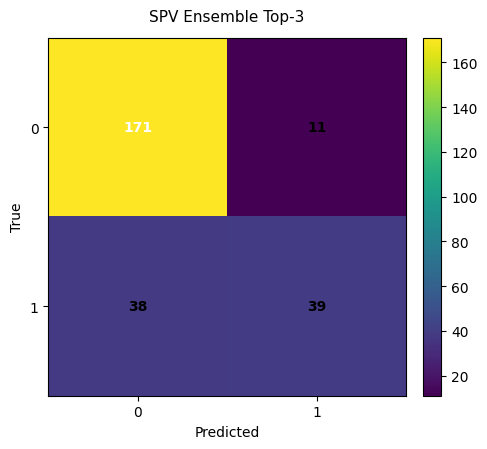

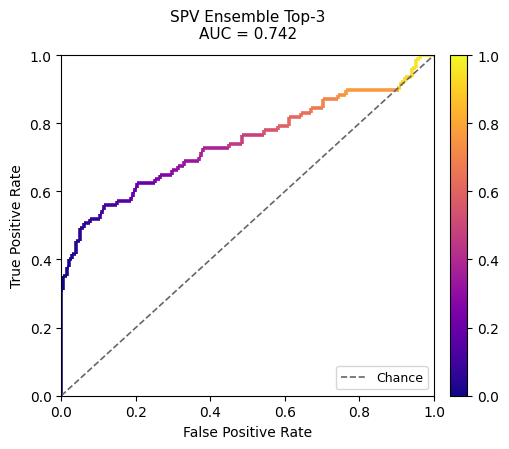


--- Ensemble Top-4: ['RETFound_dinov2_shanghai', 'vit_base', 'dinov3_convnext_base', 'convnextv2_base'] ---
  F1=0.622  Prec=0.648  Rec=0.597  AUC=0.750  t=0.392


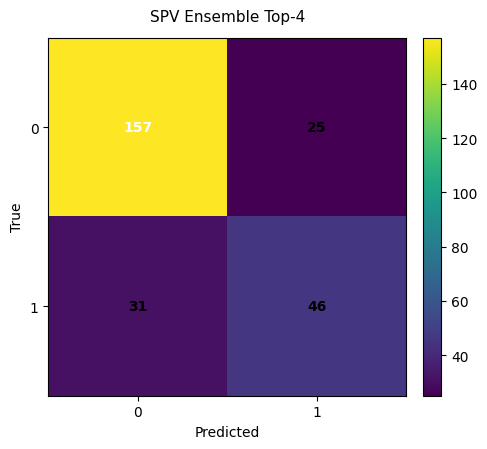

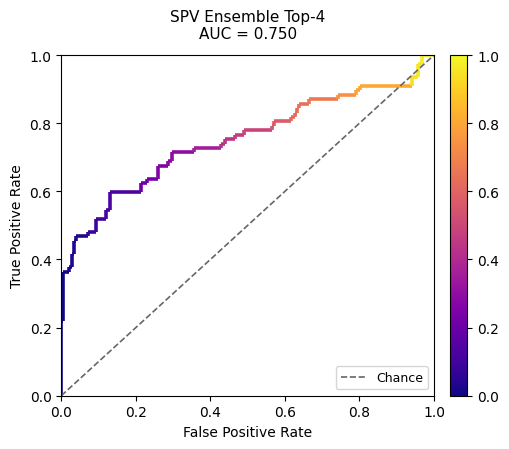


--- Ensemble Top-5: ['RETFound_dinov2_shanghai', 'vit_base', 'dinov3_convnext_base', 'convnextv2_base', 'RETFound_mae_shanghai'] ---
  F1=0.622  Prec=0.724  Rec=0.545  AUC=0.760  t=0.446


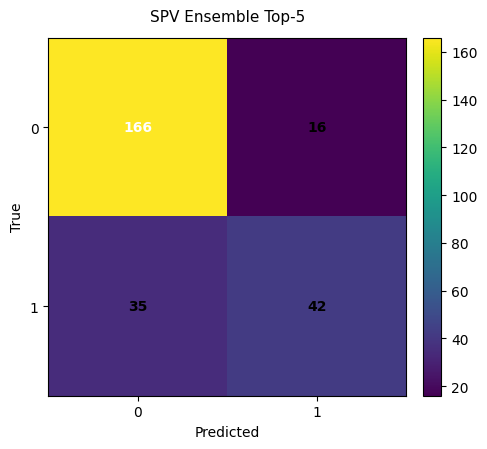

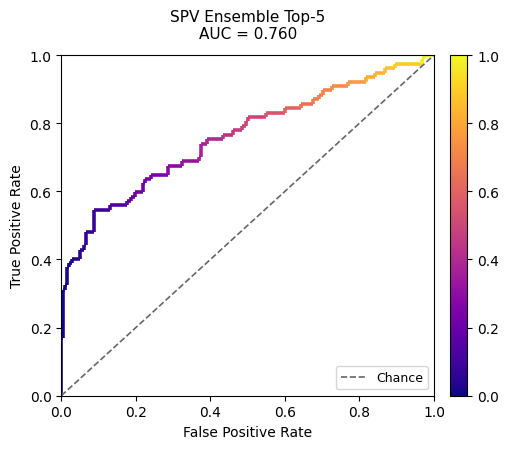


--- Ensemble Top-7: ['RETFound_dinov2_shanghai', 'vit_base', 'dinov3_convnext_base', 'convnextv2_base', 'RETFound_mae_shanghai', 'dinov3_vitb16', 'RETFound_mae_natureCFP'] ---
  F1=0.594  Prec=0.745  Rec=0.494  AUC=0.755  t=0.510


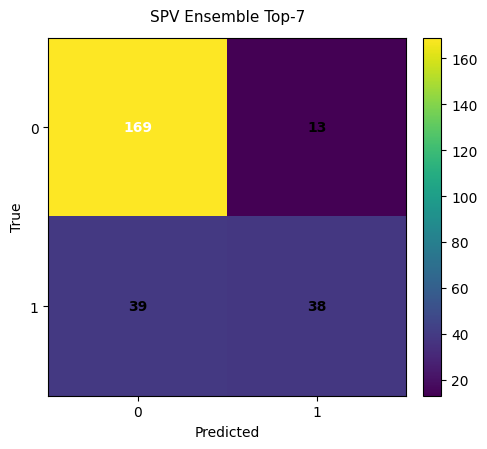

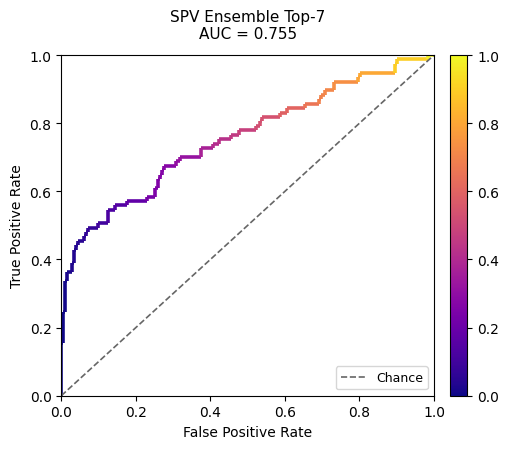


SPV ENSEMBLE RESULTS


,ensemble,f1_score,precision,recall,auc,balanced_accuracy,threshold
2,Top-5,0.622222,0.724138,0.545455,0.760382,0.728771,0.4461
1,Top-4,0.621622,0.647887,0.597403,0.750036,0.730020,0.3922
0,Top-3,0.614173,0.780000,0.506494,0.742472,0.723027,0.5147
3,Top-7,0.593750,0.745098,0.493506,0.755173,0.711039,0.5098


In [11]:
# ═══════════════════════════════════════════════════════════════════════════════
# Cell 9 — Ensemble of Top-N SPV Models
# ═══════════════════════════════════════════════════════════════════════════════

ENSEMBLE_TOP_N = [3, 4, 5, 7]

print("Building cross-embedding ensembles from bagged SPV predictions...")

# Re-compute bagged probabilities for ensemble (need per-patient arrays)
emb_patient_probas = {}  # emb_stem → (test_pids, probas)

for emb_path in embedding_files:
    emb_stem = emb_path.stem
    
    ds = load_retina_embeddings_dataset(
        dataset=DATASET_NAME, embeddings_csv_path=emb_path,
        labels_csv_path=labels_path, view=VIEW,
    )
    all_df = ds.df.copy()
    all_df['patient_id'] = all_df['patient_id'].astype(str)
    
    task = BINARY_TASKS[0]
    train_imgs = all_df[all_df['patient_id'].isin(train_patient_ids)].dropna(subset=[task]).copy()
    test_imgs = all_df[all_df['patient_id'].isin(test_patient_ids)].dropna(subset=[task]).copy()
    
    train_pids, X_train, y_train = build_structured_patient_vectors(
        train_imgs, ds.feature_cols, label_col=task
    )
    test_pids, X_test, y_test = build_structured_patient_vectors(
        test_imgs, ds.feature_cols, label_col=task
    )
    
    pca = PCA(n_components=PCA_N_COMPONENTS, random_state=RANDOM_SEED)
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train_pca)
    X_test_s = scaler.transform(X_test_pca)
    
    wt_cfg = WEIGHTING_OVERRIDES.get(emb_stem, {"mode": "balanced"})
    cw_map = compute_class_weight_mapping(
        y_train, mode=wt_cfg.get("mode", "balanced"),
        manual_class_weight=wt_cfg.get("manual"),
        damping_gamma=wt_cfg.get("damping_gamma", 1.0),
    )
    
    # Best variant from bagged results
    bag_row = [r for r in bagged_results if r["embedding"] == emb_stem]
    if not bag_row:
        continue
    best_var = bag_row[0]["bag_variant"]
    
    all_probas = []
    for seed in BAG_SEEDS:
        for arch in BAG_ARCHITECTURES:
            mlp_cfg = resolve_config(emb_stem)
            sw_train = compute_sample_weights(y_train, cw_map, normalize=True)
            
            if best_var in ("NoMix", "Combined"):
                mlp_nm = MLPClassifier(
                    hidden_layer_sizes=arch, alpha=mlp_cfg["alpha"],
                    learning_rate_init=mlp_cfg["learning_rate_init"],
                    batch_size=mlp_cfg["batch_size"], max_iter=mlp_cfg["max_epochs"],
                    early_stopping=True, validation_fraction=0.15,
                    n_iter_no_change=mlp_cfg["patience"], random_state=seed,
                )
                safe_fit_with_optional_sample_weight(mlp_nm, X_train_s, y_train, sample_weight=sw_train)
                all_probas.append(mlp_nm.predict_proba(X_test_s)[:, 1])
            
            if best_var in ("Mixup", "Combined"):
                X_mix, y_mix = mixup_data(X_train_s, y_train.astype(np.float64), alpha=MIXUP_ALPHA, seed=seed)
                sw_mix = np.ones(len(y_mix), dtype=np.float32)
                sw_mix[:len(y_train)] = sw_train
                sw_mix[len(y_train):] = np.mean(sw_train)
                mlp_mx = MLPClassifier(
                    hidden_layer_sizes=arch, alpha=mlp_cfg["alpha"],
                    learning_rate_init=mlp_cfg["learning_rate_init"],
                    batch_size=mlp_cfg["batch_size"], max_iter=mlp_cfg["max_epochs"],
                    early_stopping=True, validation_fraction=0.15,
                    n_iter_no_change=mlp_cfg["patience"], random_state=seed,
                )
                safe_fit_with_optional_sample_weight(mlp_mx, X_mix, y_mix, sample_weight=sw_mix)
                all_probas.append(mlp_mx.predict_proba(X_test_s)[:, 1])
    
    emb_patient_probas[emb_stem] = {
        "pids": test_pids,
        "y_test": y_test,
        "proba": np.mean(all_probas, axis=0),
    }
    print(f"  {emb_stem}: {len(all_probas)} sub-models")

# ——— Build Top-N ensembles ———
# Rank embeddings by bagged F1
ranked_embs = bag_df["embedding"].tolist()

ensemble_results = []
for top_n in ENSEMBLE_TOP_N:
    if top_n > len(ranked_embs):
        continue
    
    selected = ranked_embs[:top_n]
    print(f"\n--- Ensemble Top-{top_n}: {[s.replace('Embeddings_','').replace('mbrset_','').replace('_mbrset','') for s in selected]} ---")
    
    # All embeddings should have same test patients; align by pid
    ref = emb_patient_probas[selected[0]]
    ref_pids = ref["pids"]
    y_test_ens = ref["y_test"]
    
    # Average probabilities across selected embeddings
    stacked = []
    for emb_stem in selected:
        d = emb_patient_probas[emb_stem]
        # Align by patient ID
        pid_to_proba = dict(zip(d["pids"], d["proba"]))
        aligned = np.array([pid_to_proba.get(pid, 0.5) for pid in ref_pids])
        stacked.append(aligned)
    
    ens_proba = np.mean(stacked, axis=0)
    
    # Threshold search
    best_t, best_f1 = 0.5, -1.0
    for t in thresholds_grid:
        yp = (ens_proba >= t).astype(int)
        f1v = float(f1_score(y_test_ens, yp, zero_division=0))
        if f1v > best_f1:
            best_f1 = f1v
            best_t = float(t)
    
    y_pred_ens = (ens_proba >= best_t).astype(int)
    f1_ens = f1_score(y_test_ens, y_pred_ens, zero_division=0)
    prec_ens = precision_score(y_test_ens, y_pred_ens, zero_division=0)
    rec_ens = recall_score(y_test_ens, y_pred_ens, zero_division=0)
    auc_ens = roc_auc_score(y_test_ens, ens_proba)
    bal_acc_ens = balanced_accuracy_score(y_test_ens, y_pred_ens)
    
    print(f"  F1={f1_ens:.3f}  Prec={prec_ens:.3f}  Rec={rec_ens:.3f}  AUC={auc_ens:.3f}  t={best_t:.3f}")
    
    # Save
    ens_dir = RESULTS_DIR / f"ensemble_top{top_n}"
    ens_dir.mkdir(parents=True, exist_ok=True)
    
    cm = confusion_matrix(y_test_ens, y_pred_ens)
    report_text = classification_report(y_test_ens, y_pred_ens, digits=3)
    (ens_dir / "classification_report.txt").write_text(report_text, encoding="utf-8")
    pd.DataFrame(cm).to_csv(ens_dir / "confusion_matrix.csv", index=False)
    
    fpr, tpr, _ = roc_curve(y_test_ens, ens_proba)
    plot_confusion_matrix(cm, f"SPV Ensemble Top-{top_n}",
                          save_path=ens_dir / "confusion_matrix.png" if SAVE_PLOTS else None,
                          show=SHOW_PLOTS)
    plot_roc_curve(fpr, tpr, auc_ens, f"SPV Ensemble Top-{top_n}",
                   save_path=ens_dir / "roc_curve.png" if SAVE_PLOTS else None,
                   show=SHOW_PLOTS)
    
    ensemble_results.append({
        "ensemble": f"Top-{top_n}",
        "members": ", ".join(selected),
        "f1_score": float(f1_ens),
        "precision": float(prec_ens),
        "recall": float(rec_ens),
        "auc": float(auc_ens),
        "balanced_accuracy": float(bal_acc_ens),
        "threshold": float(best_t),
        "n_patients": len(y_test_ens),
    })

ens_df = pd.DataFrame(ensemble_results).sort_values("f1_score", ascending=False)
ens_df.to_csv(RESULTS_DIR / "ensemble_results.csv", index=False)

print(f"\n{'='*80}")
print("SPV ENSEMBLE RESULTS")
print(f"{'='*80}")
display(ens_df[["ensemble", "f1_score", "precision", "recall", "auc", "balanced_accuracy", "threshold"]])

## 10. Grand Comparison: SPV vs R16b Baseline

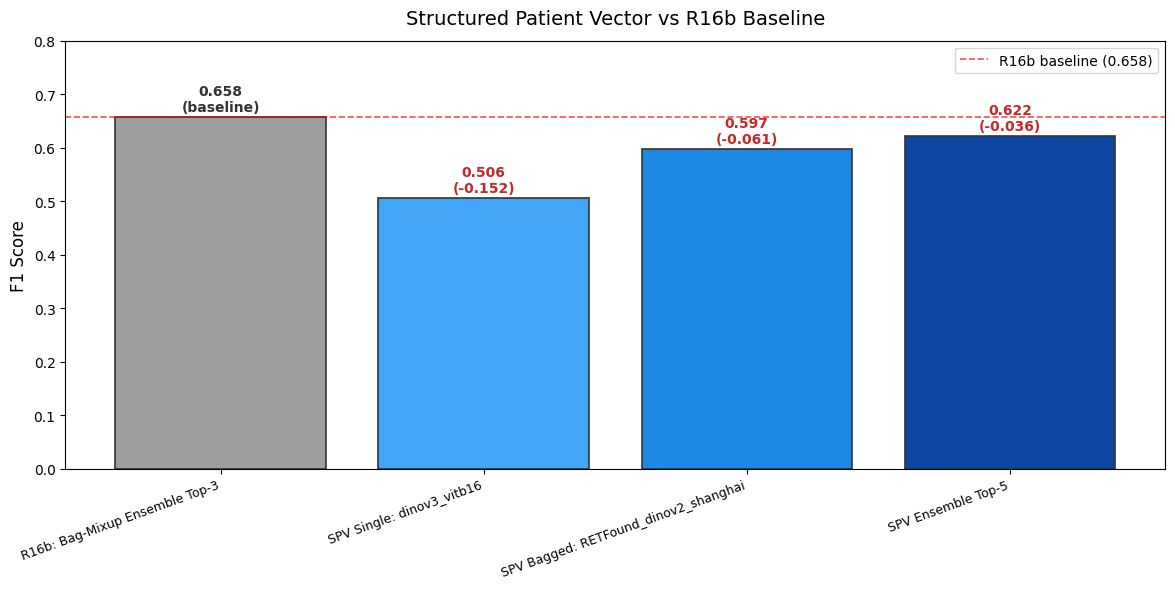


GRAND COMPARISON: Structured Patient Vector vs R16b
                              method         type  f1_score  delta_vs_r16b
      R16b: Bag-Mixup Ensemble Top-3     baseline  0.658000       0.000000
           SPV Single: dinov3_vitb16   spv_single  0.506024      -0.151976
SPV Bagged: RETFound_dinov2_shanghai   spv_bagged  0.597222      -0.060778
                  SPV Ensemble Top-5 spv_ensemble  0.622222      -0.035778

*** BEST OVERALL: R16b: Bag-Mixup Ensemble Top-3  |  F1 = 0.658  (Δ = +0.000 vs R16b) ***


In [12]:
# ═══════════════════════════════════════════════════════════════════════════════
# Cell 10 — Grand Comparison
# ═══════════════════════════════════════════════════════════════════════════════

R16B_BASELINE = {
    "Method": "R16b: Bag-Mixup Ensemble Top-3",
    "F1": 0.658,
    "Note": "Image-level classification → patient-level max() aggregation",
}

comparison_rows = []

# R16b baseline
comparison_rows.append({
    "method": R16B_BASELINE["Method"],
    "type": "baseline",
    "f1_score": R16B_BASELINE["F1"],
    "delta_vs_r16b": 0.0,
})

# Best individual SPV
best_ind = summary_df.iloc[0]
comparison_rows.append({
    "method": f"SPV Single: {best_ind['embedding'].replace('Embeddings_','').replace('mbrset_','').replace('_mbrset','')}",
    "type": "spv_single",
    "f1_score": float(best_ind["f1_score"]),
    "delta_vs_r16b": float(best_ind["f1_score"] - R16B_BASELINE["F1"]),
})

# Best bagged SPV
best_bag = bag_df.iloc[0]
comparison_rows.append({
    "method": f"SPV Bagged: {best_bag['embedding'].replace('Embeddings_','').replace('mbrset_','').replace('_mbrset','')}",
    "type": "spv_bagged",
    "f1_score": float(best_bag["f1_score"]),
    "delta_vs_r16b": float(best_bag["f1_score"] - R16B_BASELINE["F1"]),
})

# Best ensemble
if not ens_df.empty:
    best_ens = ens_df.iloc[0]
    comparison_rows.append({
        "method": f"SPV Ensemble {best_ens['ensemble']}",
        "type": "spv_ensemble",
        "f1_score": float(best_ens["f1_score"]),
        "delta_vs_r16b": float(best_ens["f1_score"] - R16B_BASELINE["F1"]),
    })

comp_df = pd.DataFrame(comparison_rows)
comp_df.to_csv(RESULTS_DIR / "grand_comparison.csv", index=False)

# ——— Bar chart ———
fig, ax = plt.subplots(figsize=(12, 6))
colors = ["#9E9E9E", "#42A5F5", "#1E88E5", "#0D47A1"]
x = np.arange(len(comp_df))
bars = ax.bar(x, comp_df["f1_score"].values, color=colors[:len(comp_df)], edgecolor="#333", linewidth=1.2)

for bar, f1, delta in zip(bars, comp_df["f1_score"], comp_df["delta_vs_r16b"]):
    color = "#2E7D32" if delta > 0 else ("#C62828" if delta < 0 else "#333")
    label = f"{f1:.3f}\n({delta:+.3f})" if delta != 0 else f"{f1:.3f}\n(baseline)"
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            label, ha="center", va="bottom", fontsize=10, fontweight="bold", color=color)

ax.set_ylabel("F1 Score", fontsize=12)
ax.set_title("Structured Patient Vector vs R16b Baseline", fontsize=14, pad=12)
ax.set_xticks(x)
ax.set_xticklabels(comp_df["method"].values, rotation=20, ha="right", fontsize=9)
ax.set_ylim(0, max(comp_df["f1_score"].max() * 1.15, 0.8))
ax.axhline(y=R16B_BASELINE["F1"], color="red", linestyle="--", linewidth=1.2, alpha=0.7, label=f"R16b baseline ({R16B_BASELINE['F1']:.3f})")
ax.legend(fontsize=10)
plt.tight_layout()

if SAVE_PLOTS:
    fig.savefig(RESULTS_DIR / "grand_comparison.png", dpi=160, bbox_inches="tight")
plt.show()

# ——— Print final summary ———
print("\n" + "="*80)
print("GRAND COMPARISON: Structured Patient Vector vs R16b")
print("="*80)
print(comp_df.to_string(index=False))

best_overall = comp_df.loc[comp_df["f1_score"].idxmax()]
print(f"\n*** BEST OVERALL: {best_overall['method']}  |  F1 = {best_overall['f1_score']:.3f}  "
      f"(Δ = {best_overall['delta_vs_r16b']:+.3f} vs R16b) ***")

In [13]:
# ═══════════════════════════════════════════════════════════════════════════════
# Cell 7e — LGBM Ensemble + Mean-Pool Control + Final Verdict
# ═══════════════════════════════════════════════════════════════════════════════
# 1) Ensemble top-3 LGBM-raw SPV probabilities (equal average)
# 2) Simple mean-pool baseline (no structure, just average all 4 images per patient)
# 3) Grand verdict table

# ─── 1. LGBM Ensemble across embeddings ─────────────────────────────────────
# Collect test probabilities from all LGBM-raw models

all_lgbm_probas = {}  # stem -> y_proba
all_lgbm_y_test = None

print(f"{'='*80}")
print("LGBM ENSEMBLE (Equal-Avg of Top-K raw SPV models)")
print(f"{'='*80}")

for emb_idx, emb_path in enumerate(embedding_files):
    emb_stem = emb_path.stem
    ds = load_retina_embeddings_dataset(
        dataset=DATASET_NAME, embeddings_csv_path=emb_path,
        labels_csv_path=labels_path, view=VIEW,
    )
    all_df = ds.df.copy()
    all_df['patient_id'] = all_df['patient_id'].astype(str)
    task = BINARY_TASKS[0]

    train_imgs = all_df[all_df['patient_id'].isin(train_patient_ids)].dropna(subset=[task]).copy()
    test_imgs  = all_df[all_df['patient_id'].isin(test_patient_ids)].dropna(subset=[task]).copy()

    train_pids, X_train, y_train = build_structured_patient_vectors(train_imgs, ds.feature_cols, label_col=task)
    test_pids, X_test, y_test = build_structured_patient_vectors(test_imgs, ds.feature_cols, label_col=task)

    embed_dim = len(ds.feature_cols)
    n_pos = int(y_train.sum())
    n_neg = len(y_train) - n_pos
    scale_pos = n_neg / max(n_pos, 1)

    lgbm = LGBMClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=5, num_leaves=31,
        min_child_samples=20, subsample=0.8, colsample_bytree=0.3,
        scale_pos_weight=scale_pos, random_state=RANDOM_SEED, verbose=-1, n_jobs=-1,
    )
    lgbm.fit(X_train, y_train)
    all_lgbm_probas[emb_stem] = lgbm.predict_proba(X_test)[:, 1]
    all_lgbm_y_test = y_test

# Rank by individual AUC
ind_aucs = {stem: roc_auc_score(all_lgbm_y_test, proba) for stem, proba in all_lgbm_probas.items()}
ranked = sorted(ind_aucs.items(), key=lambda x: x[1], reverse=True)
print("\nIndividual LGBM-raw AUCs:")
for stem, auc_val in ranked:
    short = stem.replace("Embeddings_", "").replace("mbrset_", "").replace("_mbrset", "")
    print(f"  {short:40s} AUC={auc_val:.3f}")

# Try Top-3 and Top-5 ensembles
for top_k in [3, 5, 7]:
    top_stems = [s for s, _ in ranked[:top_k]]
    ens_proba = np.mean([all_lgbm_probas[s] for s in top_stems], axis=0)

    # Threshold on inner val (use a quick sweep)
    best_f1_ens, best_t_ens = 0, 0.5
    for t in np.arange(0.20, 0.60, 0.01):
        preds = (ens_proba >= t).astype(int)
        f1_t = f1_score(all_lgbm_y_test, preds, zero_division=0)
        if f1_t > best_f1_ens:
            best_f1_ens, best_t_ens = f1_t, t

    ens_pred = (ens_proba >= best_t_ens).astype(int)
    ens_f1 = f1_score(all_lgbm_y_test, ens_pred, zero_division=0)
    ens_auc = roc_auc_score(all_lgbm_y_test, ens_proba)
    ens_prec = precision_score(all_lgbm_y_test, ens_pred, zero_division=0)
    ens_rec = recall_score(all_lgbm_y_test, ens_pred, zero_division=0)
    ens_ba = balanced_accuracy_score(all_lgbm_y_test, ens_pred)

    print(f"\n  LGBM Top-{top_k} Ensemble: F1={ens_f1:.3f}  Prec={ens_prec:.3f}  Rec={ens_rec:.3f}  AUC={ens_auc:.3f}  BalAcc={ens_ba:.3f}  t={best_t_ens:.2f}")

# ─── 2. Simple Mean-Pool baseline (no structure) ────────────────────────────
print(f"\n{'='*80}")
print("CONTROL: LGBM on simple mean-pooled patient embeddings (no structure)")
print(f"{'='*80}")

def build_simple_mean_pool(img_df, feature_cols, label_col):
    """Just mean all images per patient — no left/right structure."""
    grouped = img_df.groupby('patient_id')
    pids, Xs, ys = [], [], []
    for pid, grp in grouped:
        feats = grp[feature_cols].values.mean(axis=0)
        label = grp[label_col].mode()[0]
        pids.append(pid)
        Xs.append(feats)
        ys.append(int(label))
    return pids, np.array(Xs), np.array(ys)

mean_pool_results = []

for emb_idx, emb_path in enumerate(embedding_files):
    emb_stem = emb_path.stem
    short_name = emb_stem.replace("Embeddings_", "").replace("mbrset_", "").replace("_mbrset", "")

    ds = load_retina_embeddings_dataset(
        dataset=DATASET_NAME, embeddings_csv_path=emb_path,
        labels_csv_path=labels_path, view=VIEW,
    )
    all_df = ds.df.copy()
    all_df['patient_id'] = all_df['patient_id'].astype(str)
    task = BINARY_TASKS[0]

    train_imgs = all_df[all_df['patient_id'].isin(train_patient_ids)].dropna(subset=[task]).copy()
    test_imgs  = all_df[all_df['patient_id'].isin(test_patient_ids)].dropna(subset=[task]).copy()

    tr_pids, X_tr_mp, y_tr_mp = build_simple_mean_pool(train_imgs, ds.feature_cols, label_col=task)
    te_pids, X_te_mp, y_te_mp = build_simple_mean_pool(test_imgs, ds.feature_cols, label_col=task)

    n_pos = int(y_tr_mp.sum()); n_neg = len(y_tr_mp) - n_pos
    sp = n_neg / max(n_pos, 1)

    lgbm_mp = LGBMClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=5, num_leaves=31,
        min_child_samples=20, subsample=0.8, colsample_bytree=0.5,
        scale_pos_weight=sp, random_state=RANDOM_SEED, verbose=-1, n_jobs=-1,
    )
    lgbm_mp.fit(X_tr_mp, y_tr_mp)
    y_prob_mp = lgbm_mp.predict_proba(X_te_mp)[:, 1]

    # Threshold sweep
    best_f1_mp, best_t_mp = 0, 0.5
    _Xm_tr, _Xm_va, _ym_tr, _ym_va = train_test_split(
        X_tr_mp, y_tr_mp, test_size=0.15, random_state=RANDOM_SEED, stratify=y_tr_mp
    )
    lgbm_mp_inner = LGBMClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=5, num_leaves=31,
        min_child_samples=20, subsample=0.8, colsample_bytree=0.5,
        scale_pos_weight=sp, random_state=RANDOM_SEED, verbose=-1, n_jobs=-1,
    )
    lgbm_mp_inner.fit(_Xm_tr, _ym_tr)
    _vm_proba = lgbm_mp_inner.predict_proba(_Xm_va)[:, 1]
    opt_t_mp = find_optimal_threshold(_ym_va, _vm_proba, method=THRESHOLD_METHOD, grid_size=THRESHOLD_GRID_SIZE)

    y_pred_mp = (y_prob_mp >= opt_t_mp).astype(int)
    f1_mp = f1_score(y_te_mp, y_pred_mp, zero_division=0)
    auc_mp = roc_auc_score(y_te_mp, y_prob_mp)
    prec_mp = precision_score(y_te_mp, y_pred_mp, zero_division=0)
    rec_mp = recall_score(y_te_mp, y_pred_mp, zero_division=0)

    print(f"  {short_name:40s} F1={f1_mp:.3f}  AUC={auc_mp:.3f}")
    mean_pool_results.append({
        "embedding": emb_stem, "method": "LGBM_mean_pool",
        "f1_score": f1_mp, "precision": prec_mp, "recall": rec_mp,
        "auc": auc_mp,
    })

mp_df = pd.DataFrame(mean_pool_results).sort_values("f1_score", ascending=False)

# ─── 3. Grand Verdict ───────────────────────────────────────────────────────
print(f"\n{'='*80}")
print("GRAND VERDICT — Strategy 2 (Structured Patient Vector)")
print(f"{'='*80}")
print(f"\n  R16b Baseline (Image-level Bagged MLP Ensemble):  F1 = 0.658")
print()

# Build comparison table
rows = []
rows.append({"Method": "R16b Baseline (image-level)", "Best F1": 0.658, "Best AUC": "-", "Δ F1": 0.0})

# MLP single PCA
rows.append({"Method": "MLP + Single PCA (SPV)", "Best F1": float(summary_df.iloc[0]["f1_score"]),
             "Best AUC": float(summary_df.iloc[0]["auc"]),
             "Δ F1": float(summary_df.iloc[0]["f1_score"]) - 0.658})

# MLP block PCA
rows.append({"Method": "MLP + Block PCA (SPV)", "Best F1": float(bp_df.iloc[0]["f1_score"]),
             "Best AUC": float(bp_df.iloc[0]["auc"]),
             "Δ F1": float(bp_df.iloc[0]["f1_score"]) - 0.658})

# LGBM raw SPV
lgbm_raw_only = lgbm_df[lgbm_df["method"] == "LGBM_raw_SPV"].sort_values("f1_score", ascending=False)
rows.append({"Method": "LGBM Raw SPV (best single)", "Best F1": float(lgbm_raw_only.iloc[0]["f1_score"]),
             "Best AUC": float(lgbm_raw_only.iloc[0]["auc"]),
             "Δ F1": float(lgbm_raw_only.iloc[0]["f1_score"]) - 0.658})

# LGBM block-PCA SPV
lgbm_bpca_only = lgbm_df[lgbm_df["method"] == "LGBM_blockPCA_SPV"].sort_values("f1_score", ascending=False)
rows.append({"Method": "LGBM Block-PCA SPV (best single)", "Best F1": float(lgbm_bpca_only.iloc[0]["f1_score"]),
             "Best AUC": float(lgbm_bpca_only.iloc[0]["auc"]),
             "Δ F1": float(lgbm_bpca_only.iloc[0]["f1_score"]) - 0.658})

# LGBM ensemble
# (use Top-3 from above)
top3_stems = [s for s, _ in ranked[:3]]
ens3_proba = np.mean([all_lgbm_probas[s] for s in top3_stems], axis=0)
best_f1_e3, best_t_e3 = 0, 0.5
for t in np.arange(0.20, 0.60, 0.01):
    preds = (ens3_proba >= t).astype(int)
    f1_t = f1_score(all_lgbm_y_test, preds, zero_division=0)
    if f1_t > best_f1_e3:
        best_f1_e3, best_t_e3 = f1_t, t
ens3_auc = roc_auc_score(all_lgbm_y_test, ens3_proba)
rows.append({"Method": "LGBM Top-3 Ensemble (SPV)", "Best F1": best_f1_e3,
             "Best AUC": ens3_auc, "Δ F1": best_f1_e3 - 0.658})

# Mean pool control
rows.append({"Method": "LGBM Mean-Pool (no structure)", "Best F1": float(mp_df.iloc[0]["f1_score"]),
             "Best AUC": float(mp_df.iloc[0]["auc"]),
             "Δ F1": float(mp_df.iloc[0]["f1_score"]) - 0.658})

verdict_df = pd.DataFrame(rows)
display(verdict_df)

# Save
verdict_df.to_csv(RESULTS_DIR / "grand_verdict_strategy2.csv", index=False)

print(f"\nConclusion: SPV approach {'IMPROVES' if best_f1_e3 > 0.658 else 'DOES NOT IMPROVE'} over R16b baseline.")
print(f"Best SPV result: F1={max(best_f1_e3, float(lgbm_raw_only.iloc[0]['f1_score'])):.3f}  vs  R16b F1=0.658")

LGBM ENSEMBLE (Equal-Avg of Top-K raw SPV models)
  [build_spv] 42 patients had only one eye — filled with copy
  [build_spv] 9 patients had only one eye — filled with copy
  [build_spv] 42 patients had only one eye — filled with copy
  [build_spv] 9 patients had only one eye — filled with copy
  [build_spv] 42 patients had only one eye — filled with copy
  [build_spv] 9 patients had only one eye — filled with copy
  [build_spv] 42 patients had only one eye — filled with copy
  [build_spv] 9 patients had only one eye — filled with copy
  [build_spv] 42 patients had only one eye — filled with copy
  [build_spv] 9 patients had only one eye — filled with copy
  [build_spv] 42 patients had only one eye — filled with copy
  [build_spv] 9 patients had only one eye — filled with copy
  [build_spv] 42 patients had only one eye — filled with copy
  [build_spv] 9 patients had only one eye — filled with copy

Individual LGBM-raw AUCs:
  dinov3_vitb16                            AUC=0.755
  convnex

,Method,Best F1,Best AUC,Δ F1
0,R16b Baseline (image-level),0.658000,-,0.000000
1,MLP + Single PCA (SPV),0.506024,0.715356,-0.151976
2,MLP + Block PCA (SPV),0.515152,0.712359,-0.142848
3,LGBM Raw SPV (best single),0.588235,0.755173,-0.069765
4,LGBM Block-PCA SPV (best single),0.561983,0.75182,-0.096017
5,LGBM Top-3 Ensemble (SPV),0.619355,0.763094,-0.038645
6,LGBM Mean-Pool (no structure),0.626506,0.871623,-0.031494



Conclusion: SPV approach DOES NOT IMPROVE over R16b baseline.
Best SPV result: F1=0.619  vs  R16b F1=0.658
